In [64]:
import json
import os
import sys

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from astropy.cosmology import Planck15
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.special import gammainc, rel_entr

from PIL import Image

os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [2]:
sys.path.append(os.path.join(os.getcwd(), "../rjpop"))
import data
import plot
import utils
from xp import xp

sys.path.insert(0, os.path.join(os.getcwd(), "../scripts"))
from macros import (
    load_megadict, load_hpinfo, leaf_samples,
    R0_per_sample, total_R0_per_sample,
    trunc_gauss_ppf, fmt_ci, fmt_pct, sig_inds,
    paired_gamma_confidence, get_param_col,
)


In [3]:
plot.setup()


In [4]:
ngrid = 256
data_grid = {
    "mass_1_source": np.linspace(2, 100, 2 * ngrid),
    "mass_2_source": np.linspace(2, 100, 2 * ngrid),
    "mass_ratio": np.linspace(0, 1, ngrid),
    "chi_eff": np.linspace(-1, 1, ngrid),
    "redshift": np.linspace(0, 1.5, ngrid),
}


In [5]:
O4_path = "/data/aqc/rjmcmc_pop/results/O4"
figpath = f"{O4_path}/_figures"
figpath_dark = f"{O4_path}/_figures/dark"

def setup_data_module(model_name):
    datapath = f'{O4_path}/{model_name}'
    with open(os.path.join(datapath, 'prior.json')) as f:
        input_priordict = json.load(f)
        _ = data.process_input_priordict(input_priordict)

def get_draw_ctx(model_name, model_sig=None, submodel=False):
    datapath = f'{O4_path}/{model_name}'
    fn = "submodel_draw_ctxs.npy" if submodel else "model_draw_ctxs.npy"
    draw_ctx = np.load(os.path.join(datapath, "data", fn), allow_pickle=True).item()
    if model_sig is None:
        return draw_ctx
    if model_sig not in draw_ctx:
        raise ValueError(f"Model signature {model_sig} not found in draw context. Expecting one of {draw_ctx.keys()}")
    return draw_ctx[model_sig]

def get_ppds(model_name, model_sig=None, param=None, submodel=False):
    datapath = f"/data/aqc/rjmcmc_pop/results/O4/{model_name}/data"
    fn = "ppds_submodels.npy" if submodel else "ppds.npy"
    ppds_dict = np.load(os.path.join(datapath, fn), allow_pickle=True).item()
    if param is None:
        return ppds_dict
    ppds_dict = ppds_dict[f"{param}_labelled"]
    if model_sig in ppds_dict:
        return ppds_dict[model_sig]
    else:
        raise ValueError(f"Model signature {model_sig} not found in ppds dict for parameter {param}. Expecting one of {ppds_dict.keys()}")

def get_comp_label_info(model_name):
    return get_ppds(model_name)["comp_labels"]

def save_plot(filename, fig=None, dpi=300, bbox_inches="tight", **savefig_kwargs):
    """
    Save the current figure as PDF (normal) and PNG (transparent background,
    inverted colours for dark-background presentations).

    Parameters
    ----------
    filename : str
        Base filename without extension. Saved to ``figpath``.
    fig : matplotlib.figure.Figure, optional
        Figure to save. Uses ``plt.gcf()`` if None.
    dpi : int
        DPI for the PNG output.
    bbox_inches : str
        Bounding-box mode passed to ``savefig``.
    **savefig_kwargs
        Extra arguments forwarded to ``fig.savefig`` for the PDF.
    """

    if fig is None:
        fig = plt.gcf()

    pdf_path = os.path.join(figpath, f"{filename}.pdf")
    fig.savefig(pdf_path, bbox_inches=bbox_inches, **savefig_kwargs)

    png_path = os.path.join(figpath_dark, f"{filename}.png")
    fig.savefig(png_path, bbox_inches=bbox_inches, transparent=True, dpi=dpi)

    img = Image.open(png_path).convert("RGBA")
    arr = np.array(img)
    arr[:, :, :3] = 255 - arr[:, :, :3]
    Image.fromarray(arr).save(png_path)

In [6]:
A_name = r"$10\,M_\odot$ " + plot.textsc_ify("peak")
B_name = r"$30\,M_\odot$ " + plot.textsc_ify("peak")
C_name = plot.textsc_ify("high-spin continuum")

comp_name_dict = {
    "A": A_name,
    "B": B_name,
    "C": C_name,
    "PL A": C_name,
    "PL B": B_name,
    "gauss A": A_name,
    "gauss B": B_name,
}

model_title_fn_dict = {
    "2 local": lambda x: f"\\texttt{{{x}}} - 2 components",
    "A, B": lambda x: f"\\texttt{{{x}}} - 2 components",
    "A, B, C": lambda x: f"\\texttt{{{x}}} - 3 components",
    "3 local": lambda x: f"\\texttt{{{x}}} - 3 components",
    "PL A, gauss A, gauss B": lambda x: f"\\texttt{{{x}}} - 1 {{{plot.textsc_ify('pl')}}} + 2 {{{plot.textsc_ify('gauss')}}}",
}

def get_title(model_name, model_sig):
    if model_sig in model_title_fn_dict:
        return model_title_fn_dict[model_sig](model_name)
    return f"\\texttt{{{model_name}}} - {plot.textsc_ify(model_sig)}"


In [7]:
GWTC_path = "/work/aqc/data/GWTC_data/processed"

with np.load(f"{GWTC_path}/GWTC2p1_3_4_PE_samples.npz") as f:
    PE_samples = {
        k: xp.asarray(v, dtype=xp.float32) for k, v in f.items() if k != "chirp_mass_source"
    }
print(PE_samples.keys())

with np.load(f"{GWTC_path}/GW241011_GW241110_PE_samples.npz") as f:
    GW241011_GW241110_PE_samples = {
        k: xp.asarray(v, dtype=xp.float32) for k, v in f.items() if k != "chirp_mass_source"
    }
print(GW241011_GW241110_PE_samples.keys())

event_names = np.loadtxt(f"{GWTC_path}/GWTC2p1_3_4_waveforms.txt", dtype=str)[:, 0]
event_names_list = event_names.tolist()
event_names_idx_lookup = {s: i for i, s in enumerate(event_names_list)}

GW24_event_names = ["GW241011", "GW241110"]

print(PE_samples["redshift"].shape, len(event_names))


dict_keys(['mass_1_source', 'mass_2_source', 'mass_ratio', 'redshift', 'chi_eff', 'prior'])
dict_keys(['mass_1_source', 'mass_2_source', 'mass_ratio', 'redshift', 'chi_eff', 'prior'])
(153, 6913) 153


## Histograms

In [65]:
def plot_hp_histogram(model_name, model_sig, hp_idxs, submodel=False, samples=None, param_latex=None,
                      ax=None, comp_name_dict=None, setup=False, add_labels=False, return_samples=False,
                      **hist_kwargs):

    if setup:
        setup_data_module(model_name)

    megadict = load_megadict(model_name)
    labels = megadict["labels"]
    if samples is None:
        samples = megadict["samples"]
    if submodel:
        sig_names, model_inds = megadict["submodel_sig_names"], megadict["submodel_inds"]
    else:
        sig_names, model_inds = megadict["sig_names"], megadict["model_inds"]

    comp_label_info = get_comp_label_info(model_name)
    sig_idx = sig_names.index(model_sig)

    if isinstance(hp_idxs, int):
        hp_idxs = [hp_idxs] * (len(data.branch_names) - 1)

    if ax is None:
        fig, ax = plt.subplots()

    print("\n" + get_title(model_name, model_sig))
    res = {}
    for bn, hp_idx in zip(data.branch_names[:-1], hp_idxs, strict=True):
        b_samples = samples[bn][model_inds[sig_idx]][..., hp_idx]
        b_labels = labels[bn][model_inds[sig_idx]]
        for comp_sig, comp_name, color in zip(
            comp_label_info["comp_sigs"], comp_label_info["comp_names"], comp_label_info["colors"], strict=True
        ):
            if comp_sig[0] == bn:
                mask = b_labels == comp_sig[1]
                if np.mean(mask) > 0.01:
                    label = comp_name_dict.get(comp_name, comp_name) if comp_name_dict else comp_name
                    hist_kwargs_ = dict(label=label, color=color) | hist_kwargs
                    if add_labels:
                        comp_samples = np.nansum(b_samples * mask, axis=1)
                    else:
                        comp_samples = b_samples[mask].ravel()
                    if return_samples:
                        res[label] = comp_samples
                    low, med, high = np.percentile(comp_samples, [5, 50, 95])
                    print(f"{label}: {med:.2f} +{high-med:.2f} -{med-low:.2f}")
                    ax.hist(comp_samples, **hist_kwargs_, density=True)

    if param_latex is None:
        param_latex = data.hp_ordering[0]["__latex__"][hp_idxs[0]]
    ax.set_xlabel(param_latex)
    ax.set_ylabel(f"$p({param_latex.strip('$')})$")

    if isinstance(hist_kwargs.get("bins", None), np.ndarray):
        ax.set_xlim(hist_kwargs["bins"][0], hist_kwargs["bins"][-1])

    if return_samples:
        return ax, res
    return ax



\texttt{skewt_z} - 3 components
$10\,M_\odot$ $\textsc{peak}$: 6.00 +3.22 -3.69
$30\,M_\odot$ $\textsc{peak}$: 2.48 +1.52 -4.76
$\textsc{high-spin continuum}$: 2.15 +2.72 -6.16

\texttt{skewt_z} - 2 components
$10\,M_\odot$ $\textsc{peak}$: 5.72 +2.14 -2.76
$30\,M_\odot$ $\textsc{peak}$: 2.14 +1.47 -1.83


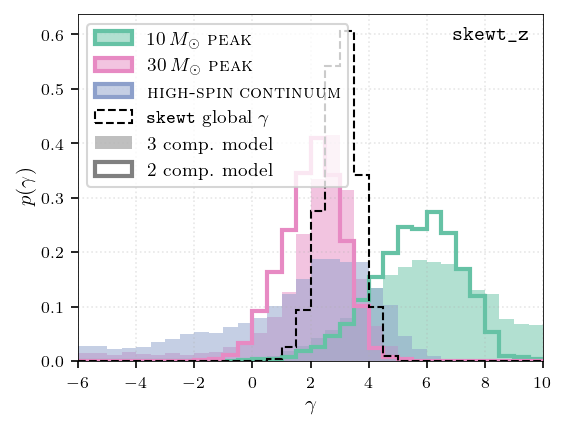

In [66]:
model_name = "skewt_z"
setup_data_module(model_name)

hist_kwargs = dict(bins=np.arange(-6, 10.1, 0.5), histtype="stepfilled", alpha=0.5)

fig, ax = plt.subplots(figsize=(4,3))
ax = plot_hp_histogram(model_name, "3 local", -2, ax=ax, comp_name_dict=comp_name_dict, **hist_kwargs)

hist_kwargs.update(dict(histtype="step", alpha=1, lw=2))
ax = plot_hp_histogram(model_name, "2 local", -2, ax=ax, comp_name_dict=comp_name_dict, **hist_kwargs)

hist_kwargs["lw"] = 1
nonevolving_skewt_gamma = load_megadict("skewt")["samples"]["global"][..., 0].ravel()
ax.hist(nonevolving_skewt_gamma, color="k", linestyle="dashed", density=True,
        label=r"\texttt{skewt} global $\gamma$", **hist_kwargs)

h_orig, l = ax.get_legend_handles_labels()
l_unique, l_inds = np.unique(l, return_index=True)
h_orig = [h_orig[i] for i in l_inds]
l = l_unique.tolist()
h = []
for handle in h_orig[:-1]:
    fc = handle.get_facecolor()
    h.append(Patch(facecolor=to_rgba(fc, alpha=0.5), edgecolor=to_rgba(fc, alpha=1.0), lw=2))
h.append(h_orig[-1])
h.extend([Patch(facecolor='gray', alpha=0.5), Patch(facecolor=(1,1,1,0), edgecolor='gray', lw=2, alpha=1)])
l.extend(["3 comp. model", "2 comp. model"])
ax.legend(h, l, fontsize=9)

ax.text(0.97, 0.97, r"\texttt{skewt\_z}", transform=ax.transAxes, ha='right', va='top', fontsize=10)
save_plot("skewt_z_gamma_hist")


\texttt{skewt} - 3 components
$10\,M_\odot$ $\textsc{peak}$: 0.77 +0.12 -0.12
$30\,M_\odot$ $\textsc{peak}$: 0.19 +0.12 -0.11
$\textsc{high-spin continuum}$: 0.02 +0.08 -0.02

\texttt{NPLNP} - 1 {$\textsc{pl}$} + 2 {$\textsc{gauss}$}
$\textsc{high-spin continuum}$: 0.11 +0.20 -0.08
$10\,M_\odot$ $\textsc{peak}$: 0.77 +0.08 -0.18
$30\,M_\odot$ $\textsc{peak}$: 0.12 +0.07 -0.05


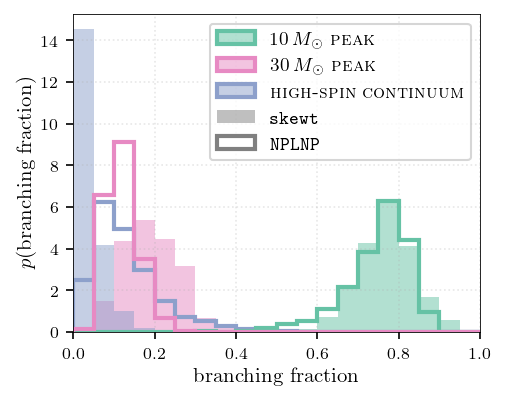

In [67]:
bf_latex = r"$\mathrm{branching~fraction}$"

def get_branching_fracs_dict(model_name):
    setup_data_module(model_name)
    samples = load_megadict(model_name)["samples"]
    rates = [v[..., [-1]] for k, v in samples.items() if k != "global"]
    tot_rate = np.nansum(np.concatenate(rates, axis=1), axis=1, keepdims=True)
    sample_bfs = {}
    for bn, rate in zip(samples.keys(), rates, strict=False):
        sample_bfs[bn] = rate / tot_rate
    return sample_bfs

hist_kwargs = dict(bins=np.arange(0, 1.01, 0.05), histtype="stepfilled", alpha=0.5)
bfs = get_branching_fracs_dict("skewt")
ax = plot_hp_histogram("skewt", "3 local", 0, samples=bfs, param_latex=bf_latex,
                       comp_name_dict=comp_name_dict, setup=False, add_labels=True, **hist_kwargs)

hist_kwargs.update(dict(histtype="step", alpha=1, lw=2))
bfs = get_branching_fracs_dict("NPLNP")
ax = plot_hp_histogram("NPLNP", "PL A, gauss A, gauss B", 0, ax=ax, samples=bfs,
                       param_latex=bf_latex, submodel=True, comp_name_dict=comp_name_dict,
                       setup=False, add_labels=True, **hist_kwargs)

h_orig, l = ax.get_legend_handles_labels()
l_unique, l_inds = np.unique(l, return_index=True)
h_orig = [h_orig[i] for i in l_inds]
l = l_unique.tolist()
h = [Patch(facecolor=to_rgba(h_.get_facecolor(), alpha=0.5), edgecolor=to_rgba(h_.get_facecolor(), alpha=1.0), lw=2) for h_ in h_orig]
h.extend([Patch(facecolor='gray', alpha=0.5), Patch(facecolor=(1,1,1,0), edgecolor='gray', lw=2, alpha=1)])
l.extend([r"\texttt{skewt}", r"\texttt{NPLNP}"])
ax.legend(h, l, fontsize=9)

save_plot("branching_fracs")


\texttt{skewt_ID} - 3 components
$10\,M_\odot$ $\textsc{peak}$: -0.25 +0.76 -0.62
$30\,M_\odot$ $\textsc{peak}$: 0.80 +0.13 -0.44
$\textsc{high-spin continuum}$: 0.64 +0.28 -0.45


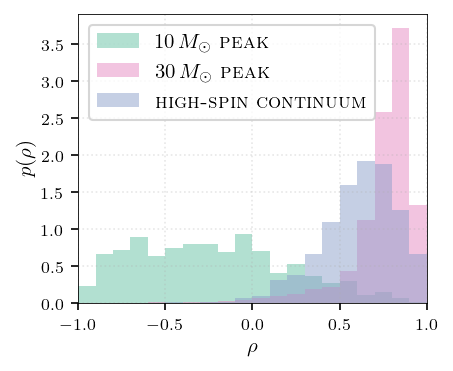

In [68]:
hist_kwargs = dict(bins=np.arange(-1, 1.01, 0.1), histtype="stepfilled", alpha=0.5)
fig, ax = plt.subplots(figsize=(3,2.5))
ax = plot_hp_histogram("skewt_ID", "3 local", 0, comp_name_dict=comp_name_dict, setup=True, ax=ax, **hist_kwargs)
ax.legend(fontsize=10)
# ax.set_title(get_title("skewt_ID", "3 local"), fontsize=11)
save_plot("skewt_ID_rho_hist")


\texttt{skewt} - 3 components
$10\,M_\odot$ $\textsc{peak}$: 0.05 +0.04 -0.04
$30\,M_\odot$ $\textsc{peak}$: -0.00 +0.04 -0.04
$\textsc{high-spin continuum}$: 0.23 +0.17 -0.18

\texttt{NPLNP} - 1 {$\textsc{pl}$} + 2 {$\textsc{gauss}$}
$\textsc{high-spin continuum}$: 0.11 +0.16 -0.12
$10\,M_\odot$ $\textsc{peak}$: 0.04 +0.03 -0.03
$30\,M_\odot$ $\textsc{peak}$: -0.01 +0.03 -0.04


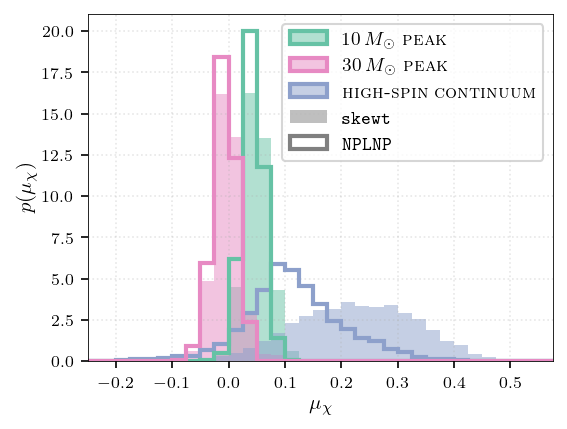

In [69]:
hist_kwargs = dict(bins=np.arange(-0.25, 0.6, 0.025), histtype="stepfilled", alpha=0.5)
fig, ax = plt.subplots(figsize=(4,3))
ax, samples = plot_hp_histogram("skewt", "3 local", 6, ax=ax, comp_name_dict=comp_name_dict, setup=True,
                                return_samples=True, **hist_kwargs)

hist_kwargs.update(dict(histtype="step", alpha=1, lw=2))
ax, samples_np = plot_hp_histogram("NPLNP", "PL A, gauss A, gauss B", [6, 4], submodel=True, ax=ax,
                                   comp_name_dict=comp_name_dict, setup=True, return_samples=True, **hist_kwargs)

h_orig, l = ax.get_legend_handles_labels()
l_unique, l_inds = np.unique(l, return_index=True)
h_orig = [h_orig[i] for i in l_inds]
l = l_unique.tolist()
h = [Patch(facecolor=to_rgba(h_.get_facecolor(), alpha=0.5), edgecolor=to_rgba(h_.get_facecolor(), alpha=1.0), lw=2) for h_ in h_orig]
h.extend([Patch(facecolor='gray', alpha=0.5), Patch(facecolor=(1,1,1,0), edgecolor='gray', lw=2, alpha=1)])
l.extend([r"\texttt{skewt}", r"\texttt{NPLNP}"])
ax.legend(h, l, fontsize=9)

save_plot("skewt_ID_mu_chi_hist")


\texttt{skewt_ID} - 3 components
$10\,M_\odot$ $\textsc{peak}$: -0.25 +0.76 -0.62
$30\,M_\odot$ $\textsc{peak}$: 0.80 +0.13 -0.44
$\textsc{high-spin continuum}$: 0.64 +0.28 -0.45

\texttt{skewt} - 3 components
$10\,M_\odot$ $\textsc{peak}$: 0.55 +0.38 -0.40
$30\,M_\odot$ $\textsc{peak}$: 0.87 +0.12 -0.28
$\textsc{high-spin continuum}$: 0.48 +0.43 -0.34


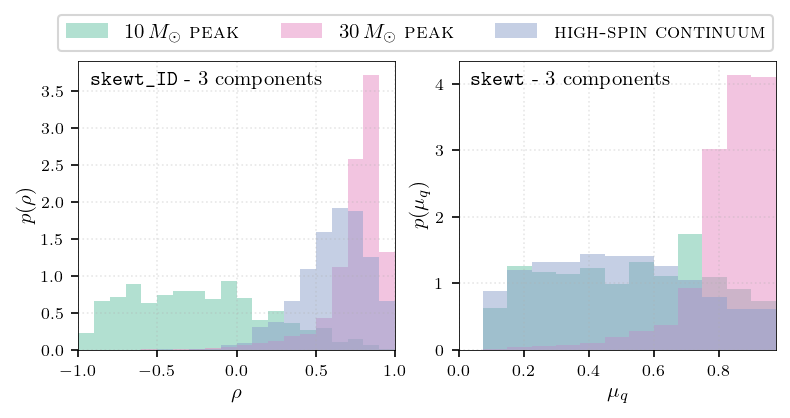

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))

hist_kwargs = dict(bins=np.arange(-1, 1.01, 0.1), histtype="stepfilled", alpha=0.5)
axes[0], samples = plot_hp_histogram("skewt_ID", "3 local", 0, ax=axes[0],
                                     comp_name_dict=comp_name_dict, setup=True, return_samples=True, **hist_kwargs)
axes[0].text(0.04, 0.97, get_title("skewt_ID", "3 local"), transform=axes[0].transAxes,
             ha='left', va='top', fontsize=10)

hist_kwargs["bins"] = np.arange(0, 1.01, 0.075)
axes[1] = plot_hp_histogram("skewt", "3 local", 4, ax=axes[1],
                            comp_name_dict=comp_name_dict, setup=True, **hist_kwargs)
axes[1].text(0.04, 0.97, get_title("skewt", "3 local"), transform=axes[1].transAxes,
             ha='left', va='top', fontsize=10)

h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, bbox_to_anchor=(0.5, 0.88), loc="lower center", ncol=len(l), fontsize=10)
save_plot("skewt_rho_mu_q_hist")

## Condensed PPD plots

In [72]:
lvk_res_path = "/work/aqc/data/GWTC_data/processed/o4a-astro"
LVK_plot = "default"

plot.setup_lvk_plot_funcs(lvk_res_path)
from popsummary.popresult import PopulationResult

if LVK_plot == "default":
    res = PopulationResult(
        fname=os.path.join(
            lvk_res_path,
            "data_release/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5",
        )
    )
elif LVK_plot == "spline":
    res = PopulationResult(
        fname=os.path.join(lvk_res_path, "data_release/BBHMassSpinRedshift_BSplineIID.h5")
    )
spin_res = PopulationResult(
    fname=os.path.join(lvk_res_path, "data_release/BBHSpin_EpsSkewNormalChiEff.h5")
)


In [82]:
def plot_all_param_ppds(model_name, model_sig, submodel=False, LVK_plot="default", labeldict=None, savefig=True):

    setup_data_module(model_name)
    comp_label_info = get_comp_label_info(model_name)
    ppds_dict = get_ppds(model_name, submodel=submodel)

    fig = plt.figure(figsize=(7, 3.5))
    gs = gridspec.GridSpec(2, 5, width_ratios=(1,1,0.1,1,1), hspace=0.35, wspace=0.15)
    axm    = fig.add_subplot(gs[0, 0:2])
    axq    = fig.add_subplot(gs[1, 0])
    axqtot = fig.add_subplot(gs[1, 1], sharex=axq, sharey=axq)
    axmtot = fig.add_subplot(gs[0, 3:5], sharex=axm, sharey=axm)
    axchi  = fig.add_subplot(gs[1, 3])
    axchitot = fig.add_subplot(gs[1, 4], sharex=axchi, sharey=axchi)

    comp_axes = [axm, axq, axchi]
    tot_axes  = [axmtot, axqtot, axchitot]
    param_names = ["mass_1_source", "mass_ratio", "chi_eff"]

    for comp_ax, tot_ax, param_name in zip(comp_axes, tot_axes, param_names):
        tot_ppds = 0
        for comp_name, color in zip(comp_label_info["comp_names"], comp_label_info["colors"]):
            if comp_name in ppds_dict[f"{param_name}_labelled"][model_sig]:
                ppds = ppds_dict[f"{param_name}_labelled"][model_sig][comp_name]
                if np.any(ppds):
                    label = comp_name if labeldict is None else labeldict.get(comp_name, comp_name)
                    plot.plot_ppds(comp_ax, data_grid[param_name], ppds, color=color, CI=None,
                                   label=label, rasterize=True, line_alpha=0.1)
                    tot_ppds = tot_ppds + ppds
        if np.any(tot_ppds):
            plot.plot_ppds(tot_ax, data_grid[param_name], tot_ppds, color="cornflowerblue",
                           CI=90, lw=0.7, secondary_lw=0.7, label="Total")
        plot.setup_and_plot_GWTC4(param_name, comp_ax, res=res, spin_res=spin_res,
                                   CI_kwargs=dict(color="dimgray", secondary_ls="dashdot"))
        plot.setup_and_plot_GWTC4(param_name, tot_ax, res=res, spin_res=spin_res,
                                   CI_kwargs=dict(color="dimgray", secondary_ls="dashdot"))
        
        if param_name == "chi_eff" and np.any(tot_ppds):
            comp_ax.set_ylim(0, 8)

    for ax in tot_axes:
        ax.set_ylabel(None)
        ax.tick_params(axis="y", which="both", labelleft=False)
    for ax in (axqtot, axchitot):
        ax.tick_params(axis="y", which="both", labelleft=False, length=0)
    for ax in comp_axes + tot_axes:
        ax.yaxis.labelpad = 1.75
        ax.xaxis.labelpad = 0
        ax.grid(True)
    for ax in (axq, axqtot):
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
        ax.set_xticklabels(["0", "0.25", "0.5", "0.75", "1"])

    all_handles, all_labels = [], []
    for ax in (axm, axmtot):
        h, l = ax.get_legend_handles_labels()
        for h_, l_ in zip(h, l, strict=True):
            if l_ not in all_labels:
                all_handles.append(h_)
                all_labels.append(l_)
    all_labels, all_handles = zip(*sorted(zip(all_labels, all_handles)))
    ncol = len(all_handles)
    if ncol > 5:
        ncol = int(np.ceil(len(all_handles) / 2))
    fig.legend(handles=all_handles, labels=all_labels, loc="lower center",
               bbox_to_anchor=(0.5, 0.88), ncol=ncol, columnspacing=1,
               frameon=False, fontsize=9)
    fig.suptitle(get_title(model_name, model_sig), y=1.02, fontsize=14)

    if savefig:
        save_plot(f"{model_name}_{utils.get_safe_fn(model_sig)}_all_param_ppds")

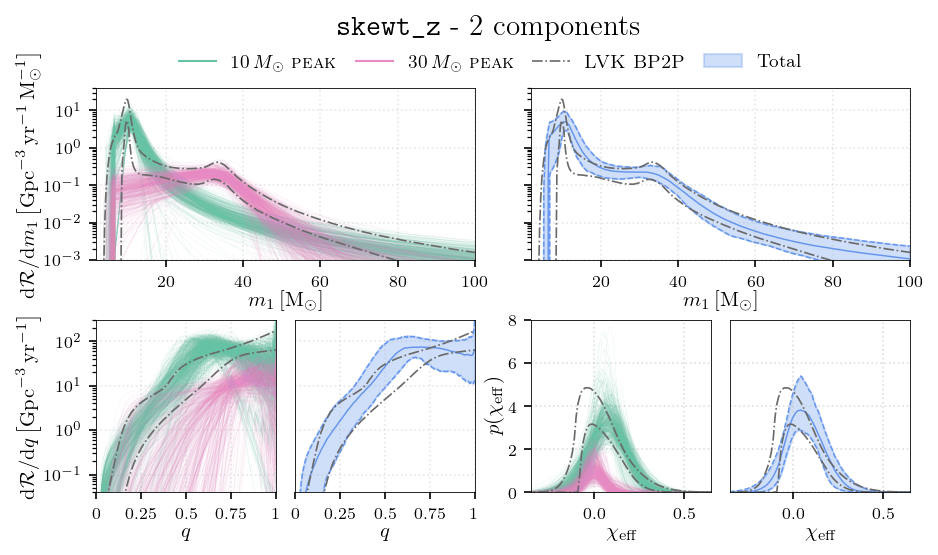

In [74]:
plot_all_param_ppds("skewt_z", "A, B", submodel=True, labeldict=comp_name_dict)

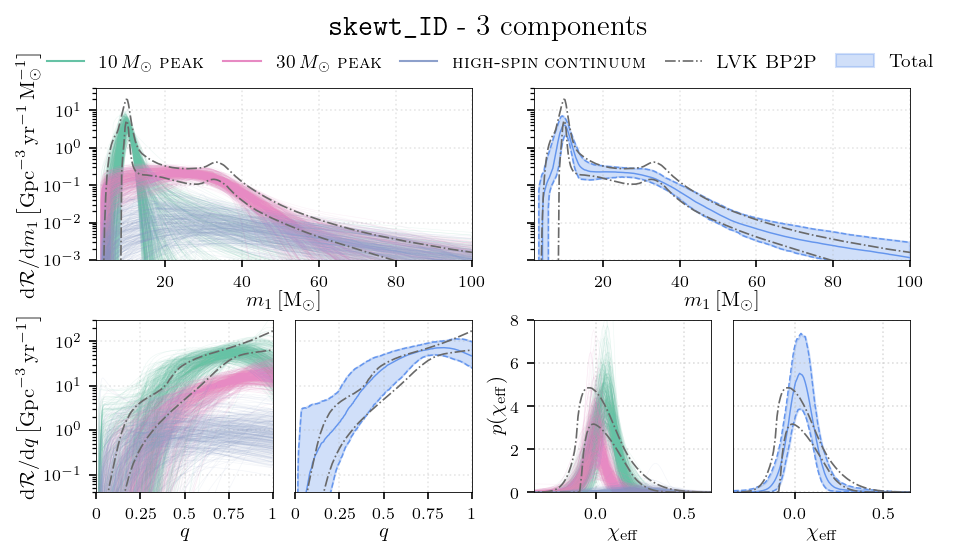

In [77]:
plot_all_param_ppds("skewt_ID", "3 local", submodel=False, labeldict=comp_name_dict)

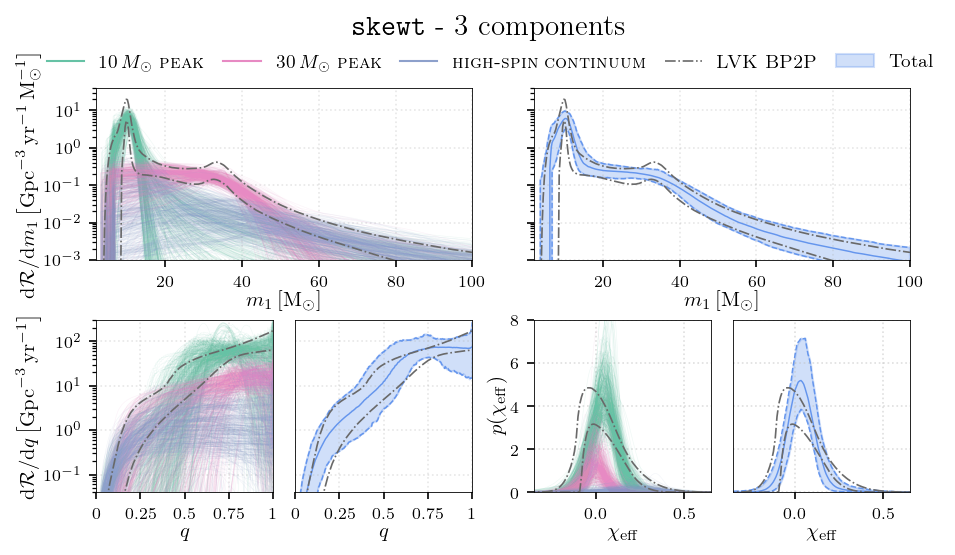

In [78]:
plot_all_param_ppds("skewt", "3 local", submodel=False, labeldict=comp_name_dict)


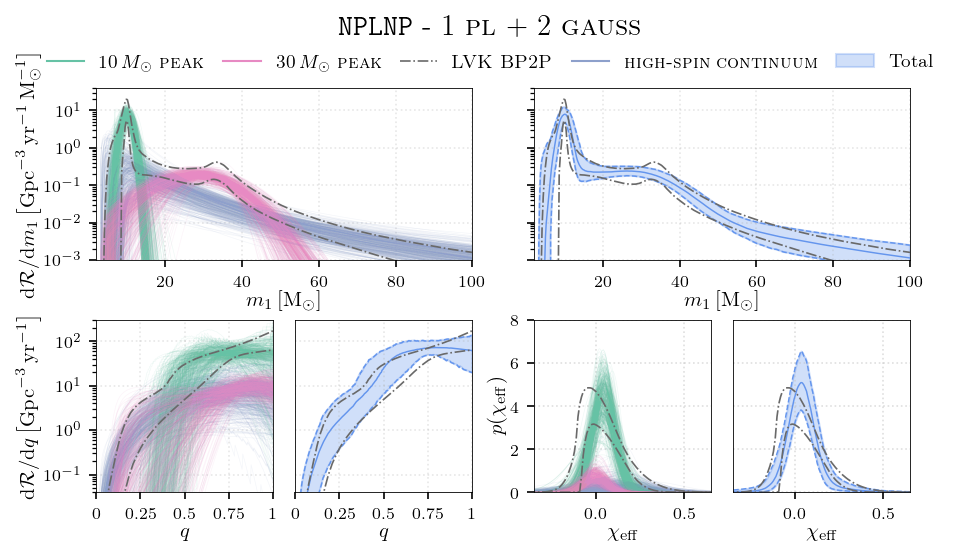

In [83]:
plot_all_param_ppds("NPLNP", "PL A, gauss A, gauss B", submodel=True, labeldict=comp_name_dict)



\texttt{skewt_ID} - 3 components
$10\,M_\odot$ $\textsc{peak}$: -0.25 +0.76 -0.62
$30\,M_\odot$ $\textsc{peak}$: 0.80 +0.13 -0.44
$\textsc{high-spin continuum}$: 0.64 +0.28 -0.45

p(q) peak:
$10\,M_\odot$ $\textsc{peak}$: 0.80 +0.13 -0.16
$30\,M_\odot$ $\textsc{peak}$: 0.94 +0.05 -0.13
$\textsc{high-spin continuum}$: 0.48 +0.50 -0.48


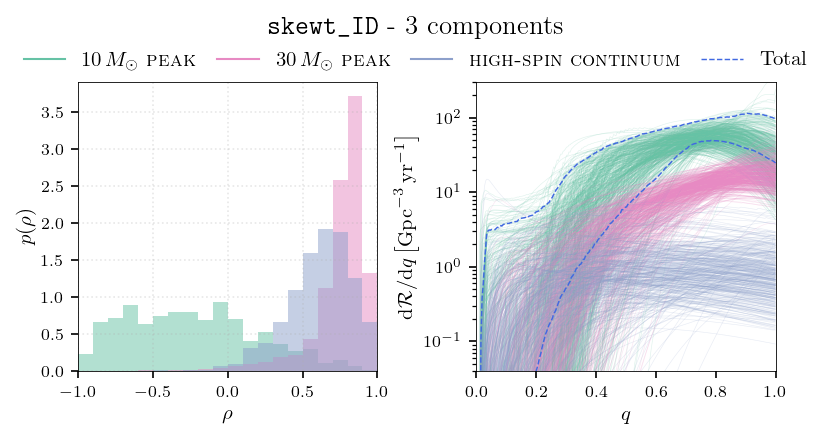

In [85]:
# p(q) of skewt_ID together with p(rho)

model_name = "skewt_ID"
model_sig = "3 local"
submodel = False
param_name = "mass_ratio"

fig, (axhist, axppd) = plt.subplots(1,2, figsize=(6, 2.5))

# histogram
hist_kwargs = dict(bins=np.arange(-1, 1.01, 0.1), histtype="stepfilled", alpha=0.5)
axhist = plot_hp_histogram(model_name, model_sig, 0, comp_name_dict=comp_name_dict, setup=True, ax=axhist, **hist_kwargs)
# ax.legend(fontsize=10)
# ax.set_title(get_title("skewt_ID", "3 local"), fontsize=11)

# ppds

setup_data_module(model_name)
comp_label_info = get_comp_label_info(model_name)
ppds_dict = get_ppds(model_name, submodel=submodel)

tot_ppds = 0
print("\np(q) peak:")
for comp_name, color in zip(comp_label_info["comp_names"], comp_label_info["colors"]):
    if comp_name in ppds_dict[f"{param_name}_labelled"][model_sig]:
        ppds = ppds_dict[f"{param_name}_labelled"][model_sig][comp_name]
        if np.any(ppds):
            label = comp_name_dict.get(comp_name, comp_name)
            plot.plot_ppds(axppd, data_grid[param_name], ppds, color=color, CI=None, label=label, rasterize=True, line_alpha=0.2)
            tot_ppds = tot_ppds + ppds
            p_q_max = data_grid[param_name][np.argmax(ppds, axis=1)]
            p_q_max_low, p_q_max_med, p_q_max_high = np.percentile(p_q_max, (5,50,95))
            print(f"{label}: {p_q_max_med:.2f} +{p_q_max_high-p_q_max_med:.2f} -{p_q_max_med-p_q_max_low:.2f}")
if np.any(tot_ppds):
    plot.plot_ppds(axppd, data_grid[param_name], tot_ppds, color="royalblue",
                    CI=90, lw=0, secondary_lw=0.7, fill_alpha=0, label=None)

# setup and label axes
plot.setup_and_plot_GWTC4(param_name, axppd, res=None, spin_res=None)

# legend
h, l = axppd.get_legend_handles_labels()
h.append(Line2D([],[], color="royalblue", ls="dashed", lw=0.7))
l.append("Total")
fig.legend(handles=h, labels=l, loc="lower center",
            bbox_to_anchor=(0.5, 0.86), ncol=len(h), columnspacing=1,
            frameon=False, fontsize=10)

fig.suptitle(get_title(model_name, model_sig), y=1.06, fontsize=13)

plt.subplots_adjust(wspace=0.33)

save_plot(f"{model_name}_{model_sig}_rho_hist_q_PPD")

## m2max

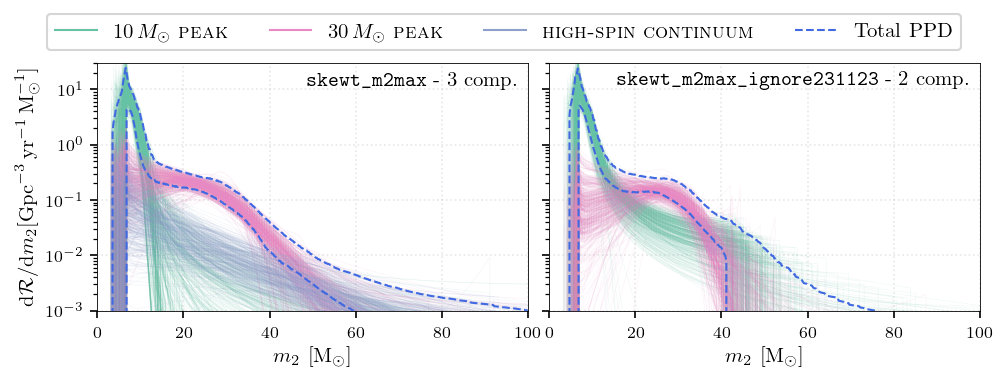

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5), sharex=True, sharey=True)
tot_ppd_kwargs = dict(color="royalblue", lw=0, secondary_lw=1, fill_alpha=0)

model_name = "skewt_m2maxglobal"
model_sig = "3 local"
setup_data_module(model_name)
comp_label_info = get_comp_label_info(model_name)
ppds_dict = get_ppds(model_name, submodel=False)
ax = axes[0]
ax.text(0.98, 0.97, get_title("skewt_m2max", model_sig).replace("components", "comp."), transform=ax.transAxes, fontsize=10, ha="right", va="top")
total = 0
for comp_name, color in zip(comp_label_info["comp_names"], comp_label_info["colors"]):
    if comp_name in ppds_dict["mass_2_source_labelled"][model_sig]:
        ppds = ppds_dict["mass_2_source_labelled"][model_sig][comp_name]
        if np.any(ppds):
            total = total + ppds
            label = comp_name_dict.get(comp_name, comp_name)
            plot.plot_ppds(ax, data_grid["mass_1_source"], ppds, color=color, CI=None,
                           label=label, rasterize=True, line_alpha=0.1)
plot.plot_ppds(ax, data_grid["mass_1_source"], total, **tot_ppd_kwargs)

model_name = "skewt_m2maxglobal_ignore231123"
model_sig = "2 local"
setup_data_module(model_name)
ppds_dict = get_ppds(model_name, submodel=False)
ax = axes[1]
ppds_combined = {
    "A": ppds_dict["mass_2_source_labelled"][model_sig]["A"] + ppds_dict["mass_2_source_labelled"][model_sig]["B"],
    "B": ppds_dict["mass_2_source_labelled"][model_sig]["C"],
}
ax.text(0.98, 0.97, get_title("skewt_m2max_ignore231123", model_sig).replace("components", "comp."), transform=ax.transAxes, fontsize=10, ha="right", va="top")
total = 0
for comp_name, color in zip(comp_label_info["comp_names"], comp_label_info["colors"]):
    if comp_name in ppds_combined:
        ppds = ppds_combined[comp_name]
        if np.any(ppds):
            total = total + ppds
            label = comp_name_dict.get(comp_name, comp_name)
            plot.plot_ppds(ax, data_grid["mass_1_source"], ppds, color=color, CI=None,
                           label=label, rasterize=True, line_alpha=0.1)
plot.plot_ppds(ax, data_grid["mass_1_source"], total, **tot_ppd_kwargs)

for ax in axes:
    plot.setup_and_plot_GWTC4("mass_2_source", ax, res=None, spin_res=None)
    ax.grid(True)
    ax.set_ylim(1e-3, 30)
    ax.set_yscale("log")
    ax.set_xlim(0, 100)
axes[0].set_ylabel(r"$\mathrm{d}\mathcal{R}/\mathrm{d}m_2 [\mathrm{Gpc}^{-3} \, \mathrm{yr}^{-1} \, \mathrm{M}_\odot^{-1}]$")
axes[1].set_ylabel(None)

h, l = axes[0].get_legend_handles_labels()
h.append(Line2D([], [], color=tot_ppd_kwargs["color"], lw=tot_ppd_kwargs["secondary_lw"], ls="--"))
l.append("Total PPD")
fig.legend(handles=h, labels=l, loc="lower center", bbox_to_anchor=(0.5, 0.91), ncol=len(h), fontsize=10)
plt.tight_layout()
plt.subplots_adjust(wspace=0.05)
save_plot("skewt_m2maxglobal_m2_pdf_comparison")

## chi_eff - q contours

In [87]:
def _get_idx_order(model_name, model_sig, ppds_dict, param="mass_1_source"):
    comp_names = []
    ppds = ppds_dict[f"{param}_labelled"][model_sig]
    for comp_name, ppd in ppds.items():
        if np.any(ppd > 1e-12):
            comp_names.append(comp_name)
    ordering = [A_name, B_name, C_name]
    original_ordering = [
        comp_name_dict[comp] if comp in comp_names else None
        for comp in ppds.keys()
    ]
    return [original_ordering.index(x) for x in ordering]

def _get_ylim(model_name, model_sig, ppds_dict, param):
    ppd = np.stack(list(ppds_dict[f"{param}_labelled"][model_sig].values()))
    ref = np.nanpercentile(ppd, 99.9)
    fac = 1e-4 if param in ["mass_1_source", "mass_2_source"] else 1e-3
    return fac * ref, 3 * ref

def plot_comp_contours(model_name, model_sig, param_x, param_y, axes=None, submodel=False, setup=True):
    if setup:
        setup_data_module(model_name)
    draw_ctxs = dict(model=get_draw_ctx(model_name), submodel=get_draw_ctx(model_name, submodel=True))
    model_ppds_dict = get_ppds(model_name)
    submodel_ppds_dict = get_ppds(model_name, submodel=True) if submodel else None
    ppds_dict = submodel_ppds_dict if submodel else model_ppds_dict

    idx_order = _get_idx_order(model_name, model_sig, ppds_dict, param_x)
    x_param_ylim = _get_ylim(model_name, model_sig, ppds_dict, param_x)
    y_param_ylim = _get_ylim(model_name, model_sig, ppds_dict, param_y)

    axes = data.plot_param_2D_contours_and_marginals(
        param_x, param_y, model_sig, draw_ctxs, model_ppds_dict,
        submodel_ppds_dict=submodel_ppds_dict, axes=axes,
        comp_label="all", rasterize=True, levels=(0.5, 0.9), figsize=(3.5, 3.5),
        idx_order=idx_order, x_param_ylim=x_param_ylim, y_param_ylim=y_param_ylim,
        comp_name_dict=comp_name_dict, ppd_kwargs=dict(line_alpha=0.15, lws=0.2)
    )
    axes[1].text(0.97, 0.97, get_title(model_name, model_sig), transform=axes[1].transAxes,
                 va="top", ha="right", fontsize=11)
    return axes

def plot_chieff_q(model_name, model_sig, submodel=False, savefig=True):
    setup_data_module(model_name)
    draw_ctxs = dict(model=get_draw_ctx(model_name), submodel=get_draw_ctx(model_name, submodel=True))
    model_ppds_dict = get_ppds(model_name)
    submodel_ppds_dict = get_ppds(model_name, submodel=True) if submodel else None
    ppds_dict = submodel_ppds_dict if submodel else model_ppds_dict

    idx_order = _get_idx_order(model_name, model_sig, ppds_dict, "mass_ratio")
    axes = plot_comp_contours(model_name, model_sig, "mass_ratio", "chi_eff", setup=False, submodel=submodel)
    legend = axes[0].legends[0]
    h, l = legend.legend_handles, [t.get_text() for t in legend.get_texts()]
    l, h = utils.sort_lists(l, h)

    tot_color = "royalblue"
    axes = data.plot_param_2D_contours_and_marginals(
        "mass_ratio", "chi_eff", model_sig, draw_ctxs, model_ppds_dict,
        submodel_ppds_dict=submodel_ppds_dict, color=tot_color, axes=axes,
        comp_label=None, CI=90, savefig=None, figpath=None, mass_ppds=None,
        return_pxy_mean=False, idx_order=idx_order, rasterize=True, levels=(0.5, 0.9),
        comp_name_dict=comp_name_dict,
        contour_kwargs=dict(linestyles="--", linewidths=1), contourf=False,
        ppd_kwargs=dict(secondary_lw=1, lw=0, fill_alpha=0)
    )
    legend.remove()
    h.append(Line2D([], [], color=tot_color, ls="--", lw=1))
    l.append(plot.textsc_ify("Total PPD"))
    axes[0].legend(handles=h, labels=l, loc="lower center", bbox_to_anchor=(0.5, 0.888), ncol=2, fontsize=8)

    if savefig:
        save_plot(f"{model_name}_{utils.get_safe_fn(model_sig)}_mass_ratio_chi_eff_contours")
    return axes


/data/aqc/rjmcmc_pop/scripts/../rjpop/data.py:1333: RuntimeWarning: invalid value encountered in divide
  np.expand_dims(comp_x_ppd, 2)


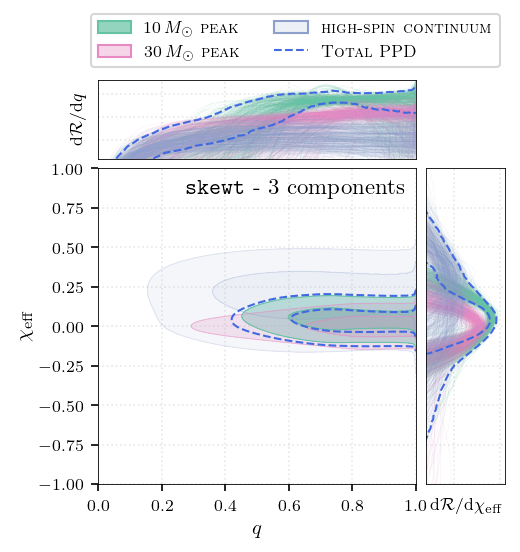

In [88]:
axes = plot_chieff_q("skewt", "3 local")


/data/aqc/rjmcmc_pop/scripts/../rjpop/data.py:1333: RuntimeWarning: invalid value encountered in divide
  np.expand_dims(comp_x_ppd, 2)


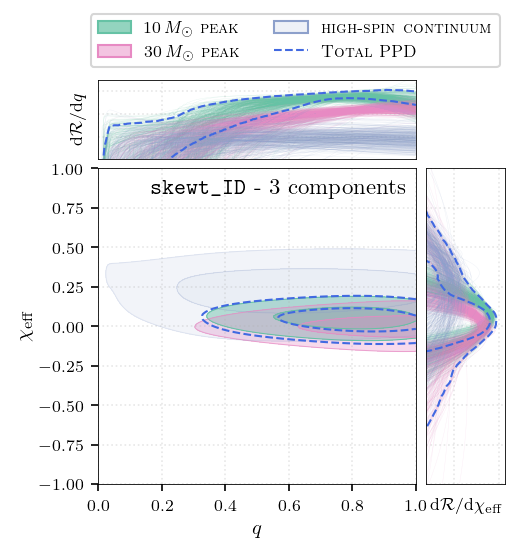

In [89]:
axes = plot_chieff_q("skewt_ID", "3 local")


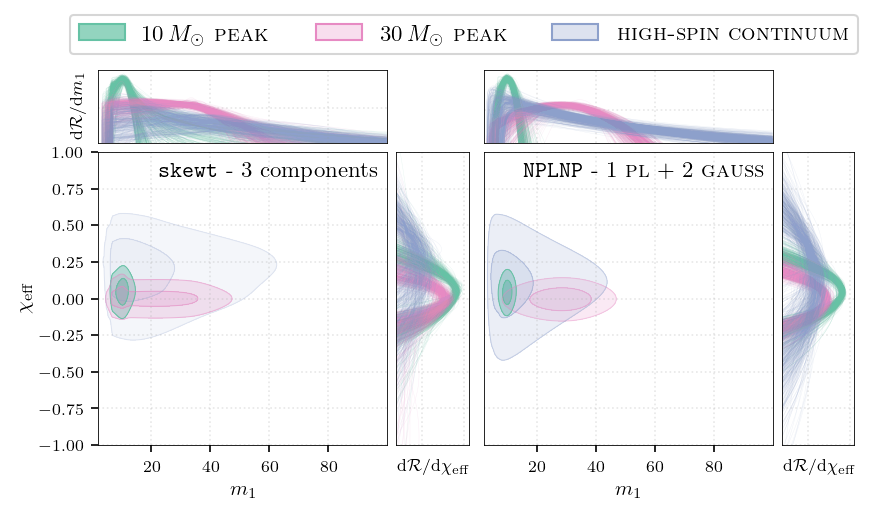

In [ ]:
fig = plt.figure(figsize=(6.5, 3.25))
outer_gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.04)

def make_joint_axes(subplot_spec):
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 2, subplot_spec=subplot_spec,
        width_ratios=(4, 1), height_ratios=(1, 4),
        wspace=0.05, hspace=0.05
    )
    ax_joint = fig.add_subplot(inner_gs[1, 0])
    ax_x = fig.add_subplot(inner_gs[0, 0], sharex=ax_joint)
    ax_y = fig.add_subplot(inner_gs[1, 1], sharey=ax_joint)
    return fig, ax_joint, ax_x, ax_y

axes_left  = make_joint_axes(outer_gs[0])
axes_right = make_joint_axes(outer_gs[1])

axes_left  = plot_comp_contours("skewt",  "3 local", "mass_1_source", "chi_eff", axes=axes_left)
fig.legends[0].remove()
axes_right = plot_comp_contours("NPLNP", "PL A, gauss A, gauss B", "mass_1_source", "chi_eff", axes=axes_right, submodel=True)

axes_right[1].set_ylabel(None)
axes_right[2].set_ylabel(None)
axes_right[1].tick_params(axis="y", which="both", labelleft=False, length=0)

axes_left[1].set_xticks([20, 40, 60, 80])
axes_right[1].set_xticks([20, 40, 60, 80]) 

save_plot("skewt_NPLNP_m1_chi_eff_contours")

## Event probabilities

In [8]:
from KDEpy import FFTKDE

In [9]:
def compute_NL_event_likelihoods(
    model_name, model_sig, submodel=False,
    PE_samples=PE_samples, ev_chunk_size=15
):
    """Compute N^m * L(d_i | {lam^m}, Lam^m) for all population posterior samples m
    and events i.  Returns array of shape (ndraws, nevs)."""
    setup_data_module(model_name)
    nevs, nsamples = PE_samples["redshift"].shape
    draw_ctx = get_draw_ctx(model_name, model_sig, submodel=submodel)
    hps = [xp.asarray(v) for v in draw_ctx["samples_input"]]

    ev_idx = 0
    NL_chunks = []
    while ev_idx < nevs:
        ev_end_idx = min(nevs, ev_idx + ev_chunk_size)
        nevs_chunk = ev_end_idx - ev_idx
        PE_samples_flat = {k: v[ev_idx:ev_end_idx].ravel() for k, v in PE_samples.items()}
        NL_chunk = 0.0
        for b_idx in range(len(data.branch_names) - 1):
            dNdtheta = 1.0
            for param in ("mass", "chi_eff", "redshift"):
                param_b_idx = b_idx if param in data.hp_ordering[b_idx] else -1
                dNdtheta = dNdtheta * data.eval_param_model(PE_samples_flat, param_b_idx, param, hps)
            dNdtheta = dNdtheta * hps[b_idx][..., -1, None]
            dNdtheta = dNdtheta / PE_samples_flat["prior"]
            dNdtheta = dNdtheta.reshape(dNdtheta.shape[:-1] + (nevs_chunk, nsamples))
            dNdtheta = xp.nansum(dNdtheta, axis=1)  # sum over ncomps -> (ndraws, nevs_chunk, nsamples)
            NL_chunk = NL_chunk + utils.to_numpy(dNdtheta)
        NL_chunks.append(np.nanmean(NL_chunk, axis=-1))  # avg over PE -> (ndraws, nevs_chunk)
        ev_idx = ev_end_idx
    return np.concatenate(NL_chunks, axis=1)  # (ndraws, nevs)


def _get_NL_path(model_name, submodel=False, tag=""):
    suffix = ("_submodel" if submodel else "") + (f"_{tag}" if tag else "")
    return f"{O4_path}/{model_name}/data/NL{suffix}.npy"


def save_NL_event_likelihoods(model_name, submodel=False, PE_samples=PE_samples, tag=""):
    """Compute and save N*L for all model signatures in the draw_ctxs file."""
    fn = "submodel_draw_ctxs.npy" if submodel else "model_draw_ctxs.npy"
    all_draw_ctxs = np.load(f"{O4_path}/{model_name}/data/{fn}", allow_pickle=True).item()
    path = _get_NL_path(model_name, submodel, tag)
    try:
        NL_dict = np.load(path, allow_pickle=True).item()
    except FileNotFoundError:
        NL_dict = {}
    for model_sig in all_draw_ctxs:
        print(f"  {model_name} / '{model_sig}'...")
        NL_dict[model_sig] = compute_NL_event_likelihoods(
            model_name, model_sig, submodel=submodel, PE_samples=PE_samples
        )
    np.save(path, NL_dict)
    print(f"Saved: {path}")


def load_NL_event_likelihoods(model_name, model_sig, submodel=False, tag=""):
    """Load precomputed N*L for the given model and model signature."""
    NL_dict = np.load(_get_NL_path(model_name, submodel, tag), allow_pickle=True).item()
    return NL_dict[model_sig]


In [10]:
# Precompute N*L for all models (run once; results saved to the data directory)
for _mn in ["skewt_z", "skewt", "NPLNP"]:
    print(f"\n=== {_mn} ===")
    save_NL_event_likelihoods(_mn, submodel=False)
    save_NL_event_likelihoods(_mn, submodel=True)


=== skewt_z ===
  skewt_z / '2 local'...
  skewt_z / '3 local'...
  skewt_z / '0'...
Saved: /data/aqc/rjmcmc_pop/results/O4/skewt_z/data/NL.npy
  skewt_z / 'A, B'...
  skewt_z / 'A, B, C'...
Saved: /data/aqc/rjmcmc_pop/results/O4/skewt_z/data/NL_submodel.npy

=== skewt ===
  skewt / '2 local'...
  skewt / '3 local'...
  skewt / '0'...
Saved: /data/aqc/rjmcmc_pop/results/O4/skewt/data/NL.npy
  skewt / 'A, B'...
  skewt / 'A, B, C'...
  skewt / 'A, B, B'...
Saved: /data/aqc/rjmcmc_pop/results/O4/skewt/data/NL_submodel.npy

=== NPLNP ===
  NPLNP / '1 PL, 2 gauss'...
  NPLNP / '2 PL, 1 gauss'...
  NPLNP / '0'...
Saved: /data/aqc/rjmcmc_pop/results/O4/NPLNP/data/NL.npy
  NPLNP / 'PL A, gauss A, gauss B'...
  NPLNP / 'PL A, PL B, gauss B'...
  NPLNP / 'PL A, PL B, gauss A'...
  NPLNP / 'PL A, PL A, gauss B'...
Saved: /data/aqc/rjmcmc_pop/results/O4/NPLNP/data/NL_submodel.npy


In [62]:
save_NL_event_likelihoods("NPLNP_z", submodel=True)

  NPLNP_z / 'PL B, gauss A, gauss B'...
  NPLNP_z / 'PL A, gauss A, gauss B'...
  NPLNP_z / 'PL A, PL B, gauss B'...
  NPLNP_z / 'PL A, PL B, gauss A'...
  NPLNP_z / 'PL A, PL A, gauss B'...
Saved: /data/aqc/rjmcmc_pop/results/O4/NPLNP_z/data/NL_submodel.npy


In [22]:
def get_pop_weighted_posterior(
    model_name, model_sig, submodel=False,
    PE_samples=PE_samples, ev_chunk_size=15, verbose=False,
    average_over_PE=True, NL=None, NL_tag="", **kwargs
):
    setup_data_module(model_name)
    nevs, nsamples = PE_samples["redshift"].shape
    draw_ctx = get_draw_ctx(model_name, model_sig, submodel=submodel)
    hps = [xp.asarray(v) for v in draw_ctx["samples_input"]]

    comp_sigs = get_comp_label_info(model_name)["comp_sigs"]
    ncomps_per_branch = [sum(1 for x in comp_sigs if x[0] == bn) for bn in data.branch_names[:-1]]

    # NL=False: skip leave-one-out correction (events not in the analysis)
    # NL=None:  load precomputed N*L from file
    # NL=array: use directly
    use_NL = NL is not False
    if use_NL:
        if NL is None:
            NL = load_NL_event_likelihoods(model_name, model_sig, submodel=submodel, tag=NL_tag)
    else:
        Ntot = 0
        for b_idx in range(len(data.branch_names) - 1):
            Ntot = Ntot + xp.nansum(data.get_branch_Ntot(b_idx, hps, labels=None), axis=-1)
        Ntot = Ntot.reshape((-1, 1, 1, 1))  # broadcast with (ndraws, ncomps, nevs, nsamples)


    ev_idx = 0
    per_ev = []
    while ev_idx < nevs:
        per_branch = []
        ev_end_idx = min(nevs, ev_idx + ev_chunk_size)
        nevs_chunk = ev_end_idx - ev_idx
        PE_samples_flat = {k: v[ev_idx:ev_end_idx].ravel() for k, v in PE_samples.items()}
        if use_NL:
            NL_chunk = xp.asarray(NL[:, ev_idx:ev_end_idx])  # (ndraws, nevs_chunk)
        for b_idx, ncomps in enumerate(ncomps_per_branch):
            dNdtheta = 1.0
            for param in ("mass", "chi_eff", "redshift"):
                param_b_idx = b_idx if param in data.hp_ordering[b_idx] else -1
                dNdtheta = dNdtheta * data.eval_param_model(PE_samples_flat, param_b_idx, param, hps)
            dNdtheta = dNdtheta * hps[b_idx][..., -1, None]
            dNdtheta = dNdtheta / PE_samples_flat["prior"]
            dNdtheta = dNdtheta.reshape(dNdtheta.shape[:-1] + (nevs_chunk, nsamples))
            if use_NL:
                dNdtheta = dNdtheta / NL_chunk[:, None, :, None]  # weight by 1/(N*L)
            else:
                dNdtheta = dNdtheta / Ntot  # weight by 1/N (no leave-one-out)
            if average_over_PE:
                dNdtheta = np.mean(utils.to_numpy(dNdtheta), axis=-1)
                labels_padded = draw_ctx["labels_input"][b_idx][..., None]
                dNdtheta = np.mean(data.aggregate_by_label(dNdtheta, labels_padded, ncomps=ncomps, comp_axis=1), axis=0)
                per_branch.append(dNdtheta)
            else:
                dNdtheta = xp.nansum(dNdtheta, axis=1)
                dNdtheta = xp.mean(dNdtheta, axis=0)
                per_branch.append(utils.to_numpy(dNdtheta))
        if average_over_PE:
            per_branch = np.concatenate(per_branch, axis=0)
            per_branch = per_branch / np.sum(per_branch, axis=0)
            per_ev.append(per_branch.T)
        else:
            per_branch = np.sum(np.stack(per_branch, axis=0), axis=0)
            per_ev.append(per_branch)
        ev_idx = ev_end_idx

    prob = np.concatenate(per_ev, axis=0)
    if verbose:
        print_info(prob, model_name, **kwargs)
    return prob

def get_event_probabilities(model_name, model_sig, submodel=False, PE_samples=PE_samples,
                            ev_chunk_size=15, verbose=False, **kwargs):
    return get_pop_weighted_posterior(
        model_name, model_sig, submodel=submodel,
        PE_samples=PE_samples, ev_chunk_size=ev_chunk_size, verbose=verbose,
        average_over_PE=True, **kwargs
    )

def get_pop_weighted_posteriors(model_name, model_sig, event_names=None, submodel=False,
                                ev_chunk_size=15, verbose=False, PE_samples=PE_samples, **kwargs):
    if event_names:
        ev_idxs = np.array([event_names_idx_lookup[name] for name in event_names])
        PE_samples_ = {k: v[ev_idxs] for k, v in PE_samples.items()}
    else:
        PE_samples_ = PE_samples
    return get_pop_weighted_posterior(
        model_name, model_sig, submodel=submodel,
        PE_samples=PE_samples_, ev_chunk_size=ev_chunk_size, verbose=verbose,
        average_over_PE=False, **kwargs
    )

In [12]:
def plot_ev_contour(param_x, param_y, ev_idx, PE_samples=PE_samples, weights=None, CI=90, ax=None, **contour_kwargs):
    x_samples = utils.to_numpy(PE_samples[param_x][ev_idx])
    y_samples = utils.to_numpy(PE_samples[param_y][ev_idx])
    if weights is None:
        weights = np.ones(x_samples.shape[0]) / x_samples.shape[0]
    else:
        weights = weights / weights.sum()
    samples = np.stack([x_samples, y_samples], axis=-1)
    mean = np.average(samples, weights=weights, axis=0)
    std = np.sqrt(np.average((samples - mean)**2, weights=weights, axis=0))
    samples_normed = (samples - mean) / std
    Neff = 1.0 / np.sum(weights**2)
    scott_bw = Neff**(-1/(2 + 4))
    grid_pts = 512
    kde = FFTKDE(kernel='gaussian', bw=scott_bw).fit(samples_normed, weights=weights)
    grid, ZZ_flat = kde.evaluate(grid_pts)
    ZZ = ZZ_flat.reshape(grid_pts, grid_pts).T
    x = np.unique(grid[:, 0]) * std[0] + mean[0]
    y = np.unique(grid[:, 1]) * std[1] + mean[1]
    flat_sorted = np.sort(ZZ.ravel())[::-1]
    cumsum = np.cumsum(flat_sorted) / flat_sorted.sum()
    level = flat_sorted[np.searchsorted(cumsum, CI/100)]
    if ax is None:
        fig, ax = plt.subplots()
    contour_kwargs = dict(linewidths=0.35) | contour_kwargs
    ax.contour(x, y, ZZ, levels=[level], **contour_kwargs)
    ax.set_xlim(data_grid[param_x][0], data_grid[param_x][-1])
    ax.set_ylim(data_grid[param_y][0], data_grid[param_y][-1])
    ax.set_xlabel(plot.param_latex[param_x])
    ax.set_ylabel(plot.param_latex[param_y])

def print_info(prob, model_name, thr=0.8, kl_thr=0.2):
    comp_names = get_comp_label_info(model_name)["comp_names"]
    real_comps = np.nonzero(np.any(prob > 0, axis=0))[0]
    prob = prob[:, real_comps]
    comp_names = [comp_names[int(i)] for i in real_comps]
    nev_notconfident, ncomp = prob.shape
    for comp_idx, comp_name in enumerate(comp_names):
        n = np.count_nonzero(prob[:, comp_idx] > thr)
        print(f"Component {comp_name} has {n} events with probability > {thr}")
        nev_notconfident -= n
    print(f"The remaining {nev_notconfident} events are not confident")
    kl = rel_entr(prob, np.ones_like(prob)/ncomp).sum(axis=1)
    n = np.count_nonzero(kl < kl_thr)
    print(f"{n} events are especially uninformative, with KL divergence < {kl_thr}")

def plot_event_prob(prob, model_name, model_sig=None, nplot=10, barheight=0.75, figsize=None,
                   plot_comp_top=True, kl_thr=0.2, saveplot=True, sanity_check=False):
    label_info = get_comp_label_info(model_name)
    colors = label_info["colors"]
    comp_names = label_info["comp_names"]
    real_comps = np.nonzero(np.any(prob > 0, axis=0))[0]
    prob = prob[:, real_comps]
    comp_names = [comp_names[int(i)] for i in real_comps]
    colors = [colors[int(i)] for i in real_comps]
    nevents, ncomp = prob.shape
    if plot_comp_top:
        nplot_tot = nplot * ncomp
    else:
        kl = rel_entr(prob, np.ones_like(prob)/ncomp).sum(axis=1)
        nplot_tot = max(int(np.count_nonzero(kl < kl_thr)), 5)
    if figsize is None:
        factor = 4 + (nplot_tot - 10) / 20
        figsize = (3.75, nplot_tot / factor)
    fig, ax = plt.subplots(figsize=figsize)
    if plot_comp_top:
        event_names_all, yticks_all = [], []
        ystart = 0
        for top_comp_idx in range(ncomp):
            comp_inds = list(range(ncomp))
            comp_sort_order = [comp_inds.pop(top_comp_idx)] + comp_inds
            sort_indices = np.lexsort([-prob[:, i] for i in list(comp_sort_order)[::-1]])[:nplot]
            prob_ = prob[sort_indices]
            event_names_all.extend(event_names[sort_indices].tolist())
            left = np.zeros(nplot)
            for comp_idx, comp_name in enumerate(comp_names):
                if np.any(prob_[:, comp_idx] > 0):
                    label = plot.textsc_ify(comp_name) if top_comp_idx == 0 else None
                    ax.barh(ystart - np.arange(nplot), prob_[:, comp_idx],
                            left=left, label=label, color=colors[comp_idx], alpha=0.7, height=barheight)
                    left += prob_[:, comp_idx]
            yticks_all.append(ystart - np.arange(nplot))
            ystart -= nplot + 0.25
        yticks_all = np.concatenate(yticks_all)
    else:
        kl = rel_entr(prob, np.ones_like(prob)/ncomp).sum(axis=1)
        sort_indices = np.argsort(kl)[:nplot_tot]
        prob_ = prob[sort_indices]
        event_names_all = event_names[sort_indices].tolist()
        yticks_all = -np.arange(nplot_tot)
        left = np.zeros(nplot_tot)
        for comp_idx, comp_name in enumerate(comp_names):
            ax.barh(yticks_all, prob_[:, comp_idx], left=left,
                    label=plot.textsc_ify(comp_name), color=colors[comp_idx], alpha=0.7, height=barheight)
            left += prob_[:, comp_idx]
    ax.set_yticks(yticks_all)
    ax.set_yticklabels(event_names_all, fontsize=8)
    ax.set_ylim(yticks_all[-1] - barheight/2 - (1-barheight), (1-barheight) + barheight/2)
    ax.set_xlabel('component probability', fontsize=11)
    ax.set_xlim(0, 1)
    ax.tick_params(axis='y', which='both', length=0)
    ax.legend(loc='lower right', fontsize=9, bbox_to_anchor=(1.02, 1), ncol=ncomp)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    if saveplot:
        suffix = "event_probabilities_top_comp" if plot_comp_top else "event_probabilities_ambiguous"
        fn_base = f"{model_name}_{utils.get_safe_fn(model_sig)}_{suffix}"
        save_plot(fn_base, bbox_inches="tight")

In [16]:
def plot_event_prob_by_name(prob, events_plot, model_name, barheight=0.75, ax=None, y0=0,
                            axis_labels=True, legend_labels=True):
    label_info = get_comp_label_info(model_name)
    colors = label_info["colors"]
    comp_names = [comp_name_dict.get(name, plot.textsc_ify(name)) for name in label_info["comp_names"]]
    real_comps = np.nonzero(np.any(prob > 0, axis=0))[0]
    real_comps = real_comps[np.argsort([comp_names[int(i)] for i in real_comps])]
    prob = prob[:, real_comps]
    comp_names = [comp_names[int(i)] for i in real_comps]
    colors = [colors[int(i)] for i in real_comps]
    ev_inds = np.array([event_names_idx_lookup[name] for name in events_plot])
    ev_prob = prob[ev_inds]
    nplot, ncomp = ev_prob.shape
    if ax is None:
        factor = 4 + (nplot - 10) / 20
        fig, ax = plt.subplots(figsize=(3.75, nplot / factor))
    yticks = y0 - np.arange(nplot)
    left = np.zeros(nplot)
    for comp_idx, comp_name in enumerate(comp_names):
        label = comp_name if legend_labels else None
        ax.barh(yticks, ev_prob[:, comp_idx], left=left, label=label,
                color=colors[comp_idx], alpha=0.7, height=barheight)
        left += ev_prob[:, comp_idx]
    if axis_labels:
        ax.set_yticks(yticks)
        ax.set_yticklabels(events_plot, fontsize=8)
        ax.set_ylim(yticks[-1] - barheight/2 - (1-barheight), (1-barheight) + barheight/2)
        ax.set_xlabel('component probability', fontsize=11)
        ax.set_xlim(0, 1)
        ax.tick_params(axis='y', which='both', length=0)
        ax.legend(loc='lower right', fontsize=9, bbox_to_anchor=(1.02, 1), ncol=ncomp)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()

def plot_top_events_of_comps(prob, model_name, nplot=10, barheight=0.75, figsize=None):
    comp_names = [comp_name_dict.get(name, plot.textsc_ify(name)) for name in get_comp_label_info(model_name)["comp_names"]]
    real_comps = np.nonzero(np.any(prob > 0, axis=0))[0]
    real_comps = real_comps[np.argsort([comp_names[int(i)] for i in real_comps])]
    ncomp = len(real_comps)
    nplot_tot = nplot * ncomp
    if figsize is None:
        factor = 4 + (nplot_tot - 10) / 20
        figsize = (3.75, nplot_tot / factor)
    fig, ax = plt.subplots(figsize=figsize)
    ystart = 0
    yticks_all, events_plot_all = [], []
    for top_comp_idx in real_comps:
        events_plot = np.sort(event_names[np.argsort(-prob[:, top_comp_idx])[:nplot]]).tolist()
        plot_event_prob_by_name(prob, events_plot, model_name, barheight=barheight, ax=ax, y0=ystart, axis_labels=False)
        yticks_all.append(ystart - np.arange(nplot))
        events_plot_all.extend(events_plot)
        ystart -= nplot + 0.25
    ax.set_yticks(np.concatenate(yticks_all))
    ax.set_yticklabels(events_plot_all, fontsize=8)
    ax.set_ylim(yticks_all[-1][0] - barheight/2 - (1-barheight), (1-barheight) + barheight/2)
    ax.set_xlabel('component probability', fontsize=11)
    ax.set_xlim(0, 1)
    ax.tick_params(axis='y', which='both', length=0)
    ax.legend(loc='lower right', fontsize=9, bbox_to_anchor=(1.02, 1), ncol=ncomp)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()

def italicize(x):
    x = x.replace("_", r"\_")
    return r"$\mathit{" + x + "}$"

def sort_paired_lists(a, b):
    common = sorted(set(a) & set(b))
    only_a = sorted(set(a) - set(b))
    only_b = sorted(set(b) - set(a))
    common_it = [italicize(x) for x in common]
    return common + only_a, common + only_b, common_it + only_a, common_it + only_b


In [13]:
prob_skewt = get_event_probabilities("skewt", "3 local")
prob_NPLNP = get_event_probabilities("NPLNP", "PL A, gauss A, gauss B", submodel=True)

In [14]:
ev_idx = [i for i, name in enumerate(event_names_list) if name.startswith("GW231123")][0]
print("skewt high-mass tail probability of GW231123:", np.amax(prob_skewt[ev_idx]))
print("NPLNP high-mass tail probability of GW231123:", np.amax(prob_NPLNP[ev_idx]))

skewt high-mass tail probability of GW231123: 0.7474925639915342
NPLNP high-mass tail probability of GW231123: 0.999999999999995


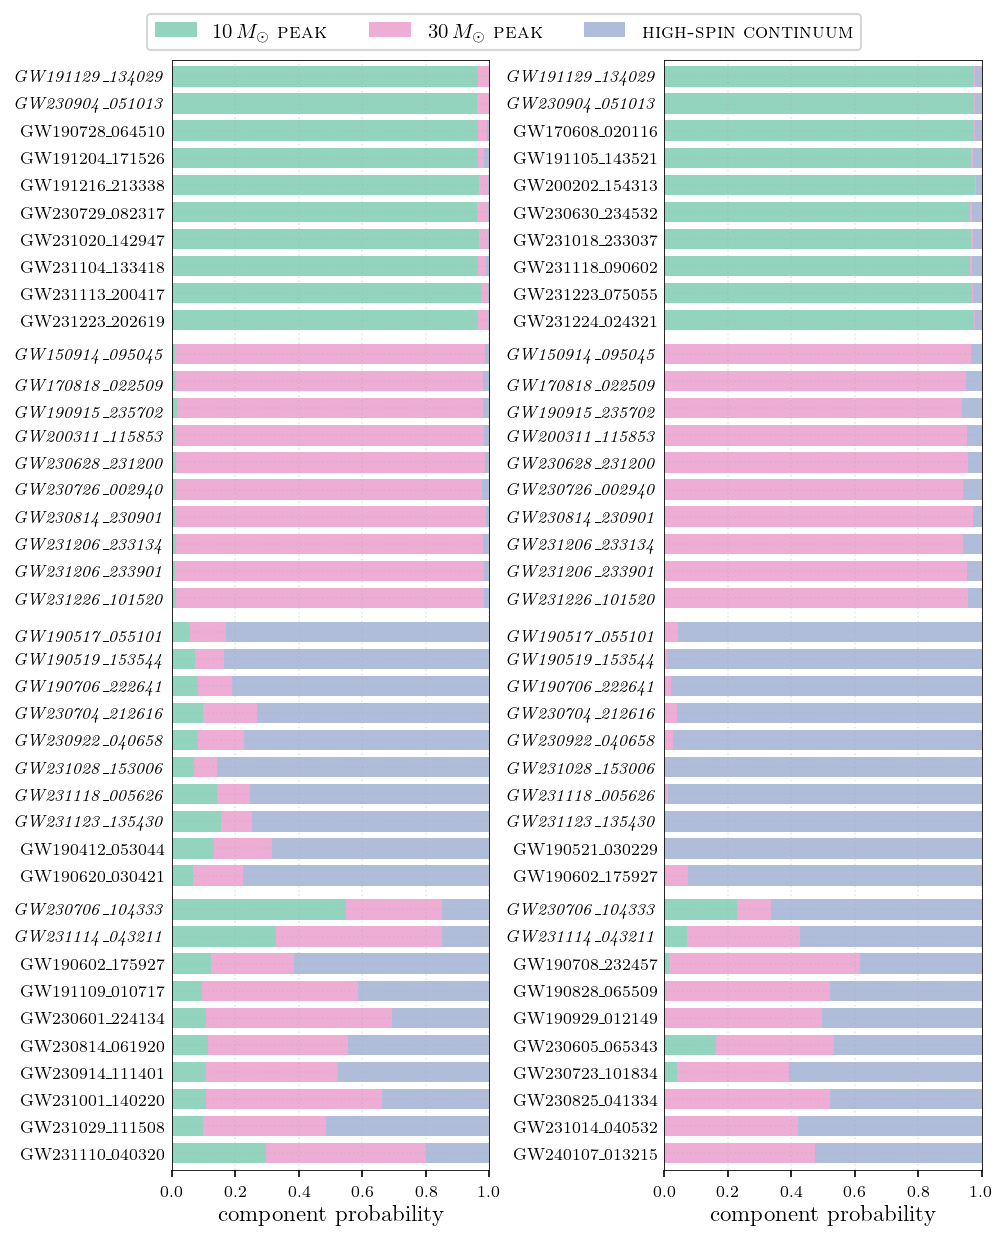

In [17]:
figsize = (7, 8.25)
nplot = 10
barheight = 0.75

top_events_skewt, top_events_NPLNP = [], []
for prob, model_name, top_evs_list in zip((prob_skewt, prob_NPLNP), ("skewt", "NPLNP"), (top_events_skewt, top_events_NPLNP)):
    label_info = get_comp_label_info(model_name)
    comp_names_loc = [comp_name_dict.get(name, plot.textsc_ify(name)) for name in label_info["comp_names"]]
    real_comps = np.nonzero(np.any(prob > 0, axis=0))[0]
    real_comps = real_comps[np.argsort([comp_names_loc[int(i)] for i in real_comps])]
    for top_comp_idx in real_comps:
        top_evs_list.append(event_names[np.argsort(-prob[:, top_comp_idx])[:nplot]].tolist())
    kl = rel_entr(prob[:, real_comps], np.ones_like(prob[:, real_comps]) / len(real_comps)).sum(axis=1)
    top_evs_list.append(event_names[np.argsort(kl)[:nplot]].tolist())

top_events_skewt_sorted, top_events_NPLNP_sorted = [], []
skewt_labels, NPLNP_labels = [], []
for ev_skewt, ev_NPLNP in zip(top_events_skewt, top_events_NPLNP):
    sa, sb, sa_it, sb_it = sort_paired_lists(ev_skewt, ev_NPLNP)
    top_events_skewt_sorted.append(sa)
    top_events_NPLNP_sorted.append(sb)
    skewt_labels.extend(sa_it)
    NPLNP_labels.extend(sb_it)

fig, axes = plt.subplots(1, 2, figsize=figsize)
for ax, evs, ev_labels, model_name, prob in zip(
    axes, [top_events_skewt_sorted, top_events_NPLNP_sorted],
    [skewt_labels, NPLNP_labels], ["skewt", "NPLNP"], (prob_skewt, prob_NPLNP)
):
    ystart = 0
    yticks_all = []
    for i, evs_block in enumerate(evs):
        plot_event_prob_by_name(prob, evs_block, model_name, barheight=barheight, ax=ax,
                                y0=ystart, axis_labels=False, legend_labels=(i == 0))
        yticks_all.append(ystart - np.arange(nplot))
        ystart -= nplot + 0.25
    yticks_all = np.concatenate(yticks_all)
    ax.set_yticks(yticks_all)
    ax.set_yticklabels(ev_labels, fontsize=8)
    ax.set_ylim(yticks_all[-1] - barheight/2 - (1-barheight), (1-barheight) + barheight/2)
    ax.set_xlabel('component probability', fontsize=11)
    ax.set_xlim(0, 1)
    ax.tick_params(axis='y', which='both', length=0)
    ax.grid(axis='x', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.97), fontsize=10, ncol=3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.55)
save_plot("skewt_NPLNP_event_probabilities")

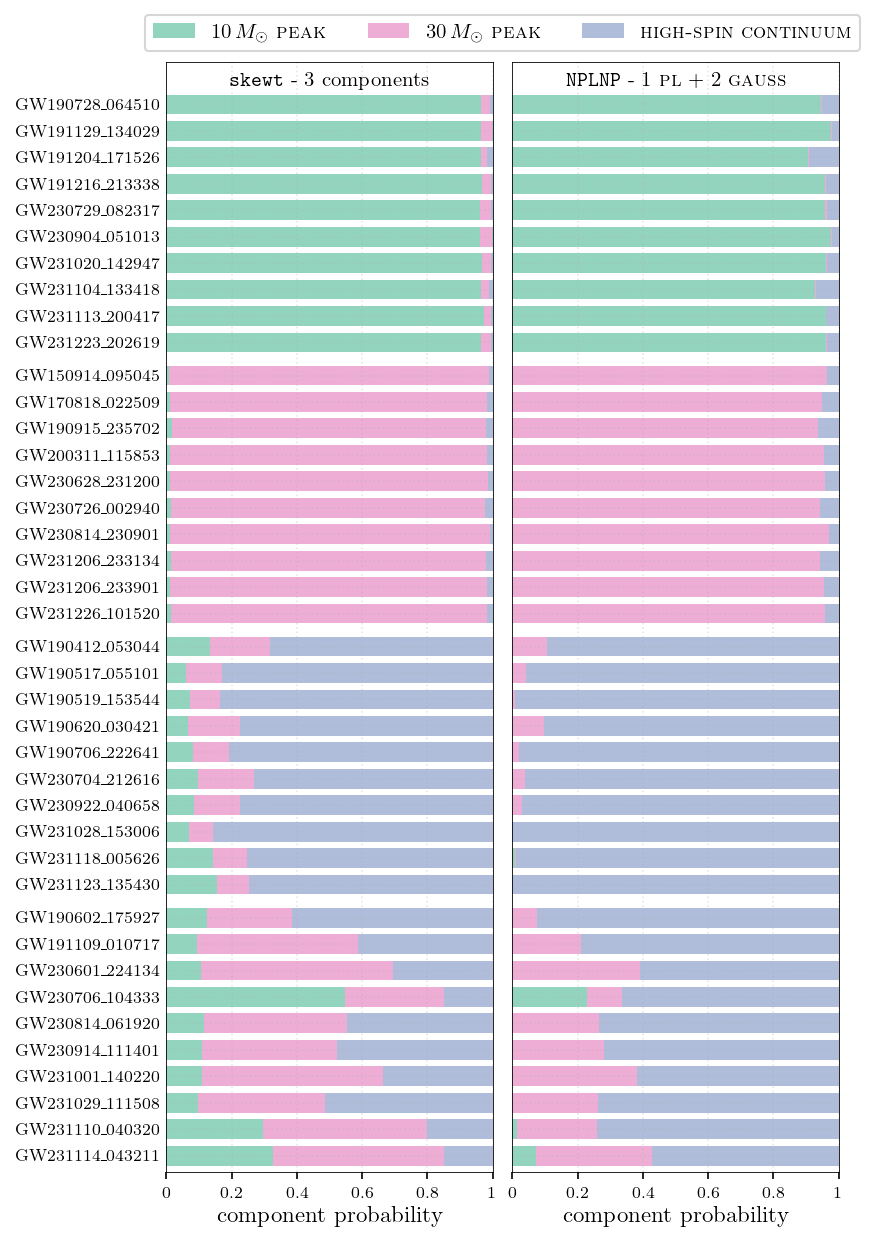

In [18]:
figsize = (6, 8.25)
nplot = 10
barheight = 0.75

prob, model_name, top_evs_list = prob_skewt, "skewt", []
label_info = get_comp_label_info(model_name)
comp_names_loc = [comp_name_dict.get(name, plot.textsc_ify(name)) for name in label_info["comp_names"]]
real_comps = np.nonzero(np.any(prob > 0, axis=0))[0]
real_comps = real_comps[np.argsort([comp_names_loc[int(i)] for i in real_comps])]
for top_comp_idx in real_comps:
    top_evs_list.append(np.sort(event_names[np.argsort(-prob[:, top_comp_idx])[:nplot]]))
kl = rel_entr(prob[:, real_comps], np.ones_like(prob[:, real_comps]) / len(real_comps)).sum(axis=1)
top_evs_list.append(np.sort(event_names[np.argsort(kl)[:nplot]]))

fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)
for ax, model_name, model_sig, prob in zip(
    axes, ["skewt", "NPLNP"], ("3 local", "PL A, gauss A, gauss B"), (prob_skewt, prob_NPLNP)
):
    ystart = 0
    yticks_all = []
    for i, evs_block in enumerate(top_evs_list):
        plot_event_prob_by_name(prob, evs_block.tolist(), model_name, barheight=barheight,
                                ax=ax, y0=ystart, axis_labels=False, legend_labels=(i == 0))
        yticks_all.append(ystart - np.arange(nplot))
        ystart -= nplot + 0.25
    yticks_all = np.concatenate(yticks_all)
    ax.grid(axis='x', alpha=0.3)
    ax.set_ylim(yticks_all[-1] - barheight/2 - (1-barheight), (1-barheight) + barheight/2 + 1)
    ax.set_xlabel('component probability', fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xticklabels(["0", "0.2", "0.4", "0.6", "0.8", "1"])
    ax.tick_params(axis='y', which='both', length=0)
    ax.set_title(get_title(model_name, model_sig), fontsize=10, y=0.9665)

axes[0].set_yticks(yticks_all)
axes[0].set_yticklabels(np.concatenate(top_evs_list), fontsize=8)
axes[1].tick_params(labelleft=False)
plt.tight_layout()
plt.subplots_adjust(wspace=0.06)
fig.canvas.draw()
handles, labels = axes[0].get_legend_handles_labels()
bbox1 = axes[0].get_position()
bbox2 = axes[1].get_position()
fig.legend(handles, labels, loc='lower center',
           bbox_to_anchor=((bbox1.x0 + bbox2.x1) / 2, max(bbox1.y1, bbox2.y1)),
           fontsize=10, ncol=3)
save_plot("skewt_NPLNP_event_probabilities_same")

### skewt_z

In [23]:
model_name = "skewt_z"
model_sig = "A, B"

prob = get_event_probabilities("skewt_z", "A, B", submodel=True)
prob_GW24 = get_event_probabilities(model_name, model_sig, submodel=True, PE_samples=GW241011_GW241110_PE_samples, NL=False)

In [24]:
# probability of hierarchical merger candidates

for ev_name in sorted("GW190517, GW231028, GW231118, GW190521, GW190519, GW190620, GW190706".split(", ")):
    ind = [i for (i, name) in enumerate(event_names_list) if name.startswith(ev_name)][0]
    print(ev_name, f"{prob[ind, 0]:.2f}", f"{prob[ind, 1]:.2f}")

print("")
# including GW241011, GW241110
for p, name in zip(prob_GW24, GW24_event_names):
    print(name, f"{p[0]:.2f}", f"{p[1]:.2f}")

print("")
# exceptional events
for ev_name in "GW190412, GW231123".split(", "):
    ind = [i for (i, name) in enumerate(event_names_list) if name.startswith(ev_name)][0]
    print(ev_name, f"{prob[ind, 0]:.2f}", f"{prob[ind, 1]:.2f}")

GW190517 0.80 0.20
GW190519 0.88 0.12
GW190521 0.80 0.20
GW190620 0.76 0.24
GW190706 0.88 0.12
GW231028 0.93 0.07
GW231118 0.93 0.07

GW241011 0.94 0.06
GW241110 0.85 0.15

GW190412 0.90 0.10
GW231123 0.66 0.34


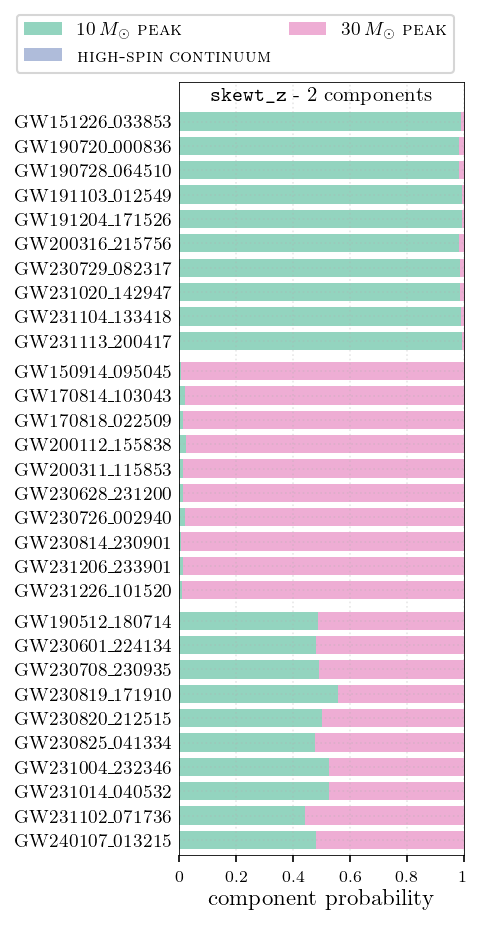

In [25]:
figsize = (3.5, 6)
nplot = 10
barheight = 0.75

top_evs_list = []
label_info = get_comp_label_info(model_name)
comp_names_loc = [comp_name_dict.get(name, plot.textsc_ify(name)) for name in label_info["comp_names"]]
real_comps = np.nonzero(np.any(prob > 0, axis=0))[0]
real_comps = real_comps[np.argsort([comp_names_loc[int(i)] for i in real_comps])]
for top_comp_idx in real_comps:
    top_evs_list.append(np.sort(event_names[np.argsort(-prob[:, top_comp_idx])[:nplot]]))
kl = rel_entr(prob[:, real_comps], np.ones_like(prob[:, real_comps]) / len(real_comps)).sum(axis=1)
top_evs_list.append(np.sort(event_names[np.argsort(kl)[:nplot]]))

fig, ax = plt.subplots(figsize=figsize)

ystart = 0
yticks_all = []
for i, evs_block in enumerate(top_evs_list):
    plot_event_prob_by_name(prob, evs_block.tolist(), model_name, barheight=barheight,
                            ax=ax, y0=ystart, axis_labels=False, legend_labels=(i == 0))
    yticks_all.append(ystart - np.arange(nplot))
    ystart -= nplot + 0.25
yticks_all = np.concatenate(yticks_all)
ax.grid(axis='x', alpha=0.3)
ax.set_ylim(yticks_all[-1] - barheight/2 - (1-barheight), (1-barheight) + barheight/2 + 1)
ax.set_xlabel('component probability', fontsize=11)
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_xticklabels(["0", "0.2", "0.4", "0.6", "0.8", "1"])
ax.tick_params(axis='y', which='both', length=0)
ax.set_title(get_title(model_name, model_sig), fontsize=10, y=0.96)

ax.set_yticks(yticks_all)
ax.set_yticklabels(np.concatenate(top_evs_list), fontsize=9)
plt.tight_layout()
plt.subplots_adjust(wspace=0.06)
fig.canvas.draw()
handles, labels = axes[0].get_legend_handles_labels()
handles = [handles[0], handles[-1], handles[1]]
labels = [labels[0], labels[-1], labels[1]]
bbox = ax.get_position()
legend = fig.legend(handles, labels, loc='lower right',
           bbox_to_anchor=(bbox.x1, bbox.y1),
           fontsize=9, ncol=2, columnspacing=1)
save_plot("skewt_z_2_local_event_probabilities")

## Pop-weighted posteriors

In [29]:
def mix_colors(colors, weights):
    rgba = np.array([to_rgba(c) for c in colors])
    weights = np.array(weights) / np.sum(weights)
    return tuple(weights @ rgba)

def plot_pop_weighted_posteriors(param_x, param_y, model_name, model_sig, submodel=False,
                                 prob=None, PE_samples=PE_samples, posterior_pop_weights=None, ax=None,
                                 legend=True, title=True, savefig=True):
    if prob is None:
        prob = get_event_probabilities(model_name, model_sig, submodel=submodel, PE_samples=PE_samples)
    if posterior_pop_weights is None:
        posterior_pop_weights = get_pop_weighted_posteriors(model_name, model_sig, submodel=submodel, PE_samples=PE_samples)
    elif posterior_pop_weights is False:
        posterior_pop_weights = [None] * len(prob)
    if ax is None:
        fig, ax = plt.subplots()
    label_info = get_comp_label_info(model_name)
    colors = label_info["colors"]
    for ev_idx, wts in enumerate(posterior_pop_weights):
        ev_prob = prob[ev_idx]
        if np.any(ev_prob > 0.75):
            color = colors[np.argmax(ev_prob)]
            zorder = 2
        else:
            color = "lightgray"
            zorder = 1
        plot_ev_contour(param_x, param_y, ev_idx, ax=ax, weights=wts, colors=[color], zorder=zorder)
    if legend:
        comp_names = [comp_name_dict.get(name, plot.textsc_ify(name)) for name in label_info["comp_names"]]
        real_comps = np.nonzero(np.any(prob > 0, axis=0))[0]
        real_comps = real_comps[np.argsort([comp_names[int(i)] for i in real_comps])]
        handles = [plt.Line2D([], [], color=colors[i], lw=0.8, label=comp_names[i]) for i in real_comps]
        ax.legend(handles=handles, fontsize=9, loc="lower right")
    if title:
        ax.set_title(get_title(model_name, model_sig), fontsize=11)
    if savefig:
        save_plot(f"{model_name}_{utils.get_safe_fn(model_sig)}_{param_x}_{param_y}_pop_weighted_posteriors")
    return ax


### skewt

In [27]:
prob_skewt = get_event_probabilities("skewt", "3 local")
wts_skewt = get_pop_weighted_posteriors("skewt", "3 local")

<Axes: title={'center': '\\texttt{skewt} - 3 components'}, xlabel='$m_1$', ylabel='$\\chi_{\\mathrm{eff}}$'>

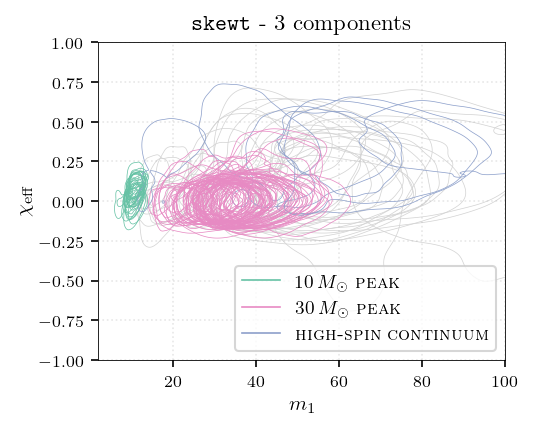

In [30]:
plot_pop_weighted_posteriors("mass_1_source", "chi_eff", "skewt", "3 local", prob=prob_skewt, posterior_pop_weights=wts_skewt)

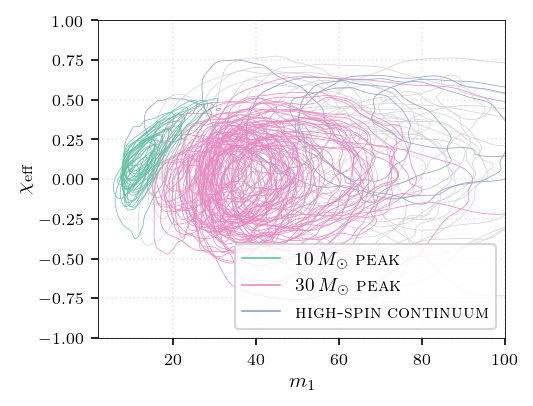

In [31]:
ax = plot_pop_weighted_posteriors("mass_1_source", "chi_eff", "skewt", "3 local",
                                  prob=prob_skewt, posterior_pop_weights=False, savefig=False)
ax.set_title(None)
save_plot("skewt_3_local_mass_1_source_chi_eff_unweighted_posteriors")

<Axes: title={'center': '\\texttt{skewt} - 3 components'}, xlabel='$m_1$', ylabel='$z$'>

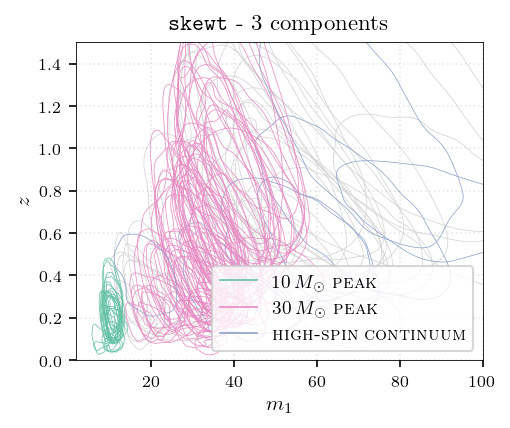

In [32]:
plot_pop_weighted_posteriors("mass_1_source", "redshift", "skewt", "3 local", prob=prob_skewt, posterior_pop_weights=wts_skewt)


<Axes: title={'center': '\\texttt{skewt} - 3 components'}, xlabel='$m_1$', ylabel='$q$'>

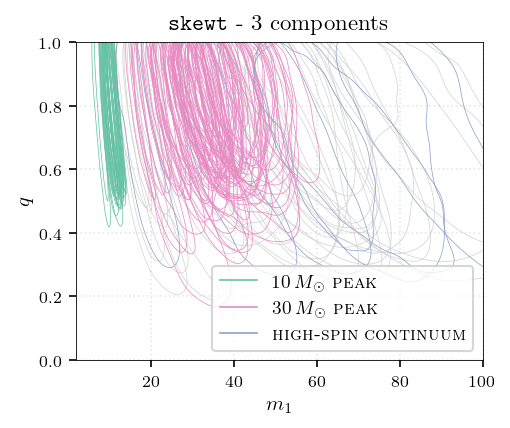

In [33]:
plot_pop_weighted_posteriors("mass_1_source", "mass_ratio", "skewt", "3 local", prob=prob_skewt, posterior_pop_weights=wts_skewt)

#### including GW241110 and GW241011

In [45]:
# also get for NPLNP

model_name, model_sig = "NPLNP", "PL A, gauss A, gauss B"
prob = get_event_probabilities(model_name, model_sig, submodel=True, PE_samples=GW241011_GW241110_PE_samples, NL=False)
print(model_name,  get_comp_label_info(model_name)["comp_names"])
for p, name in zip(prob, GW24_event_names):
    print(name, p)
wts_NPLNP = get_pop_weighted_posteriors(model_name, model_sig, submodel=True, PE_samples=GW241011_GW241110_PE_samples, NL=False)

NPLNP ['PL A', 'PL B', 'gauss A', 'gauss B']
GW241011 [9.99996099e-01 0.00000000e+00 1.19533865e-06 2.70547611e-06]
GW241110 [0.90889242 0.         0.00294415 0.08816343]


In [46]:
model_name, model_sig = "skewt", "3 local"
print(model_name,  get_comp_label_info(model_name)["comp_names"])
prob = get_event_probabilities(model_name, model_sig, PE_samples=GW241011_GW241110_PE_samples)
for p, name in zip(prob, GW24_event_names):
    print(name, p)
wts = get_pop_weighted_posteriors(model_name, model_sig, PE_samples=GW241011_GW241110_PE_samples)

skewt ['A', 'B', 'C']
GW241011 [0.05746187 0.03658606 0.90595208]
GW241110 [0.42222545 0.3197806  0.25799395]


<Axes: title={'center': '\\texttt{skewt} - 3 components'}, xlabel='$m_1$', ylabel='$\\chi_{\\mathrm{eff}}$'>

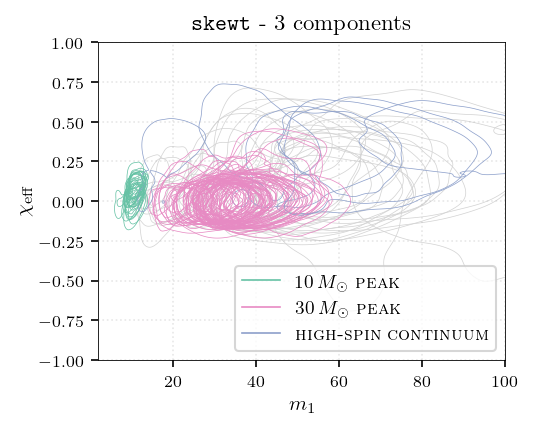

In [36]:
plot_pop_weighted_posteriors("mass_1_source", "chi_eff", "skewt", "3 local", prob=prob_skewt, posterior_pop_weights=wts_skewt)


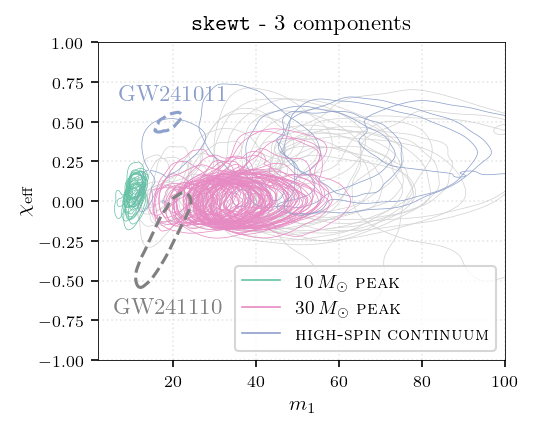

In [47]:
param_x, param_y = "mass_1_source", "chi_eff"

# fig, ax = plt.subplots()
ax = plot_pop_weighted_posteriors(param_x, param_y, model_name, model_sig, prob=prob_skewt, posterior_pop_weights=wts_skewt, savefig=False)
colors = get_comp_label_info(model_name)["colors"]
for ev_idx, (ev_prob, wt) in enumerate(zip(prob, wts)):
    if np.any(ev_prob > 0.8):
        color = colors[np.argmax(ev_prob)]
    else:
        color = "gray"
    plot_ev_contour(param_x, param_y, ev_idx, PE_samples=GW241011_GW241110_PE_samples, ax=ax, weights=wt, colors=[color], linewidths=1.5, linestyles="dashed")

    if ev_idx == 0: #GW241011
        px, py = 60, 99.7
        va, ha = "bottom", "center"
    else:
        px, py = 0, 0.02
        va, ha = "top", "left"
    x = np.percentile(utils.to_numpy(GW241011_GW241110_PE_samples[param_x][ev_idx]), px)
    y = np.percentile(utils.to_numpy(GW241011_GW241110_PE_samples[param_y][ev_idx]), py)
    if ev_idx > 0:
        x -= 5
    ax.text(x, y, GW24_event_names[ev_idx], fontsize=11, ha=ha, va=va, color=color, fontweight="bold")

save_plot(f"{model_name}_{utils.get_safe_fn(model_sig)}_{param_x}_{param_y}_pwp_with_GW241011_GW241110")

### skewt_z

In [38]:
prob_ABC = get_event_probabilities("skewt_z", "A, B, C", submodel=True)
wts_ABC = get_pop_weighted_posteriors("skewt_z", "A, B, C", submodel=True)

prob_AB = get_event_probabilities("skewt_z", "A, B", submodel=True)
wts_AB = get_pop_weighted_posteriors("skewt_z", "A, B", submodel=True)

In [39]:
def plot_ppds(model_name, model_sig, param_name, ax, submodel=False):
    comp_label_info = get_comp_label_info(model_name)
    ppds_dict = get_ppds(model_name, model_sig, param=param_name, submodel=True)
    tot_ppds = 0
    for comp_name, color in zip(comp_label_info["comp_names"], comp_label_info["colors"]):
        if comp_name in ppds_dict:
            ppds = ppds_dict[comp_name]
            tot_ppds = tot_ppds + ppds
            if np.any(ppds):
                label = comp_name_dict.get(comp_name, comp_name)
                plot.plot_ppds(ax, data_grid[param_name], ppds, color=color, CI=None,
                               label=label, rasterize=True, line_alpha=0.1)
    ax.set_xlim(data_grid[param_name][0], data_grid[param_name][-1])
    ref = np.nanpercentile(np.amax(tot_ppds, axis=0), 99)
    ax.set_yscale("log")
    ax.set_ylim(1e-4 * ref, 3 * ref)


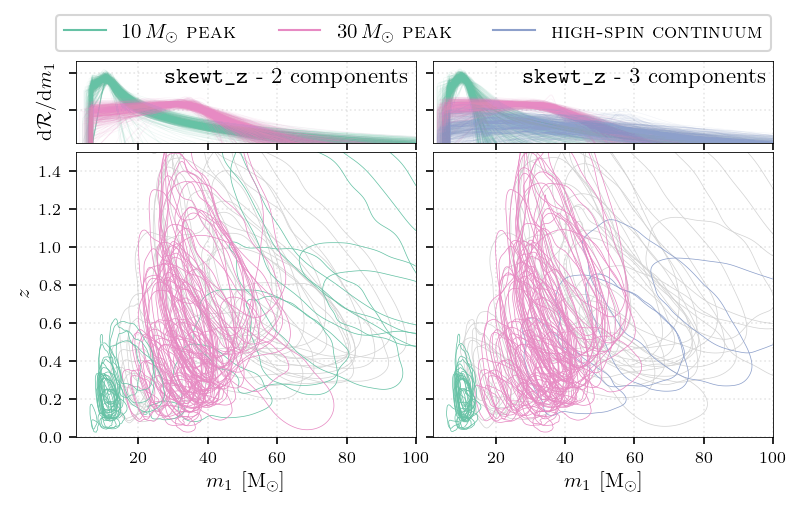

In [40]:
fig = plt.figure(figsize=(6, 3.25))
gs = gridspec.GridSpec(2, 2, height_ratios=(1, 3.5), wspace=0.05, hspace=0.05)
ax_PPD_AB    = fig.add_subplot(gs[0, 0])
ax_PPD_ABC   = fig.add_subplot(gs[0, 1], sharex=ax_PPD_AB, sharey=ax_PPD_AB)
ax_cont_AB   = fig.add_subplot(gs[1, 0], sharex=ax_PPD_AB)
ax_cont_ABC  = fig.add_subplot(gs[1, 1], sharex=ax_PPD_AB, sharey=ax_cont_AB)

plot_ppds("skewt_z", "A, B",   "mass_1_source", ax=ax_PPD_AB,  submodel=True)
plot_pop_weighted_posteriors("mass_1_source", "redshift", "skewt_z", "A, B",
                              ax=ax_cont_AB, prob=prob_AB, posterior_pop_weights=wts_AB,
                              title=False, legend=False, savefig=False)
ax_PPD_AB.text(0.98, 0.92, get_title("skewt_z", "A, B"), transform=ax_PPD_AB.transAxes,
               ha="right", va="top", fontsize=11)

plot_ppds("skewt_z", "A, B, C", "mass_1_source", ax=ax_PPD_ABC, submodel=True)
plot_pop_weighted_posteriors("mass_1_source", "redshift", "skewt_z", "A, B, C",
                              ax=ax_cont_ABC, prob=prob_ABC, posterior_pop_weights=wts_ABC,
                              title=False, legend=False, savefig=False)
ax_PPD_ABC.text(0.98, 0.92, get_title("skewt_z", "A, B, C"), transform=ax_PPD_ABC.transAxes,
                ha="right", va="top", fontsize=11)

for ax in (ax_PPD_AB, ax_PPD_ABC):
    ax.set_xlabel(None)
    ax.tick_params(axis="both", which="both", labelbottom=False, labelleft=False)
for ax in (ax_PPD_ABC, ax_cont_ABC):
    ax.set_ylabel(None)
    ax.tick_params(axis="y", which="both", labelleft=False)
for ax in (ax_cont_ABC, ax_cont_AB):
    ax.set_xlabel(r"$m_1$ [$\mathrm{M}_\odot$]")
ax_PPD_AB.set_ylabel(r"$\mathrm{d}\mathcal{R}/\mathrm{d}m_1$", labelpad=6)

h, l = ax_PPD_ABC.get_legend_handles_labels()
fig.legend(h, l, loc='lower center', bbox_to_anchor=(0.5, 0.88), ncol=len(h), fontsize=10)
save_plot("skewt_z_pop_weighted_posteriors_and_ppds_comparison")

### NPLNP

In [41]:
model_name = "NPLNP"
model_sig = "PL A, gauss A, gauss B"
prob = get_event_probabilities(model_name, model_sig, submodel=True)
wts = get_pop_weighted_posteriors(model_name, model_sig, submodel=True)


<Axes: title={'center': '\\texttt{NPLNP} - 1 {$\\textsc{pl}$} + 2 {$\\textsc{gauss}$}'}, xlabel='$m_1$', ylabel='$\\chi_{\\mathrm{eff}}$'>

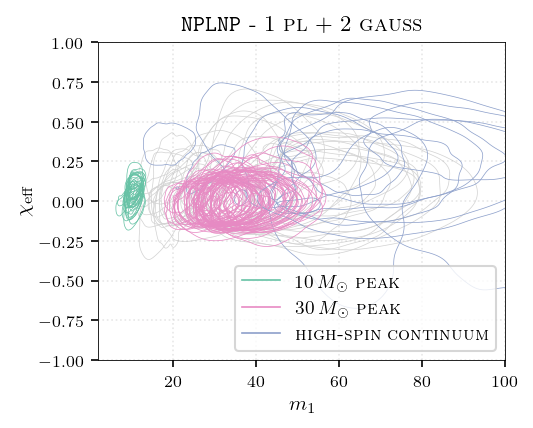

In [42]:
plot_pop_weighted_posteriors("mass_1_source", "chi_eff", model_name, model_sig, prob=prob, posterior_pop_weights=wts)


<Axes: title={'center': '\\texttt{NPLNP} - 1 {$\\textsc{pl}$} + 2 {$\\textsc{gauss}$}'}, xlabel='$m_1$', ylabel='$z$'>

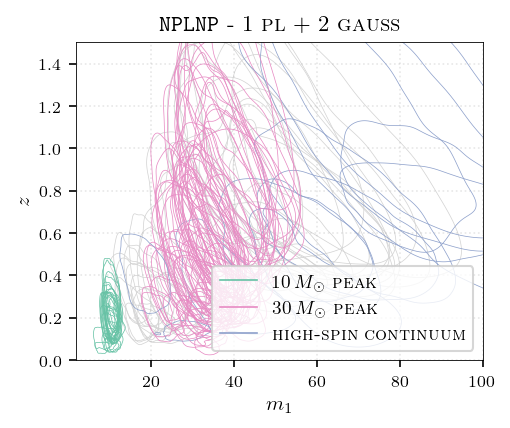

In [43]:
plot_pop_weighted_posteriors("mass_1_source", "redshift", model_name, model_sig, prob=prob, posterior_pop_weights=wts)


<Axes: title={'center': '\\texttt{NPLNP} - 1 {$\\textsc{pl}$} + 2 {$\\textsc{gauss}$}'}, xlabel='$m_1$', ylabel='$q$'>

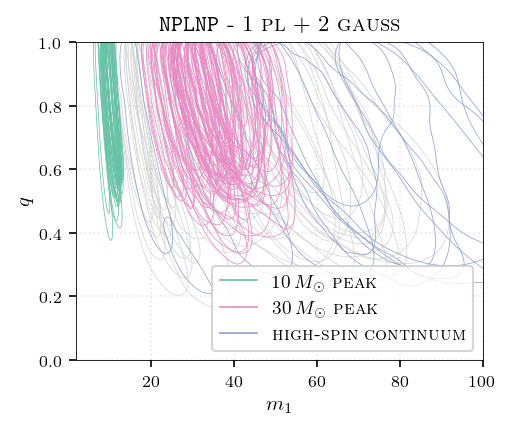

In [44]:
plot_pop_weighted_posteriors("mass_1_source", "mass_ratio", model_name, model_sig, prob=prob, posterior_pop_weights=wts)


## Delay time distributions

In [48]:
def psi_MD(z, gamma=2.7, kappa=2.9, zp=1.9):
    """Madau-Dickinson rate model."""
    return (1.0 + z) ** gamma / (1.0 + ((1.0 + z) / (1.0 + zp)) ** (gamma + kappa))

def metallicity_SF_frac(z, Zmax):
    return gammainc(0.84, Zmax**2 * 10**(0.3 * z))

ZZ = np.linspace(0, 6, 1024)
zpivot = 0.2

zz_interp = np.linspace(0, 20, 10000)
tt_interp = Planck15.lookback_time(zz_interp).value
def z_from_t(t):
    return np.interp(t, tt_interp, zz_interp)


In [49]:
dt_index_arr = [-2]
Zmax_arr = [0.1]
tmin_arr = [0.01]
psi_dict = {}
tmax = 13.5

for tmin in tmin_arr:
    tt = np.linspace(tmin, tmax, 512)
    for dt_index in dt_index_arr:
        p_tt = tt**dt_index
        for Zmax in Zmax_arr:
            z_form = z_from_t(Planck15.lookback_time(ZZ).value[:, None] + tt)
            psi = metallicity_SF_frac(z_form, Zmax) * psi_MD(z_form)
            res = np.trapezoid(psi * p_tt, tt, axis=-1)
            psi_dict[(tmin, dt_index, Zmax)] = res / np.interp(zpivot, ZZ, res)


In [57]:
def plot_and_compare_z_ppds(model_name, model_sig, submodel=False, ax=None, ev_prob=None,
                            ev_wts=None, savefig=True, comp_name_dict=comp_name_dict):
    zz = data_grid["redshift"]
    z_ppds = get_ppds(model_name, model_sig, "redshift", submodel=submodel)
    prefix = f"\\texttt{{{model_name.split('_')[0]}}}"
    if ev_prob is None:
        ev_prob = get_event_probabilities(model_name, model_sig, submodel=submodel)
    if ev_wts is None:
        ev_wts = get_pop_weighted_posteriors(model_name, model_sig, submodel=submodel)
    ev_wts = ev_wts / np.sum(ev_wts, axis=-1, keepdims=True)
    comp_label_info = get_comp_label_info(model_name)
    if ax is None:
        fig, ax = plt.subplots()
    for comp_idx, comp_name in enumerate(comp_label_info["comp_names"]):
        if comp_name in z_ppds:
            ppd = z_ppds[comp_name]
            low, med, high = np.nanpercentile(ppd, (10, 50, 90), axis=0)
            norm = np.interp(zpivot, zz, med)
            low, high = low / norm, high / norm
            color = comp_label_info["colors"][comp_idx]
            label = comp_name_dict.get(comp_name, prefix + " " + comp_name)
            if med[0] > 1e-3:
                mask = ev_prob[:, comp_idx] > 0.75
                comp_ev_wts = ev_wts[mask]
                comp_ev_zs = utils.to_numpy(PE_samples["redshift"][mask])
                comp_zmax = np.amax(np.sum(comp_ev_zs * comp_ev_wts, axis=-1)).item()
                ax.plot(zz[zz < comp_zmax], low[zz < comp_zmax], color=color, lw=0.5)
                ax.plot(zz[zz < comp_zmax], high[zz < comp_zmax], color=color, lw=0.5)
                ax.fill_between(zz[zz < comp_zmax], low[zz < comp_zmax], high[zz < comp_zmax],
                                color=color, alpha=0.1, label=label)
                ax.plot(zz[zz >= comp_zmax], low[zz >= comp_zmax], color=color, lw=0.5, ls=':')
                ax.plot(zz[zz >= comp_zmax], high[zz >= comp_zmax], color=color, lw=0.5, ls=':')
    MD_norm = psi_MD(ZZ)
    MD_norm = MD_norm / np.interp(zpivot, ZZ, MD_norm)
    ax.plot(ZZ, MD_norm, color="k", ls="-.", lw=0.8, label="Madau-Dickinson SFR")
    tmin, dt_index, Zmax = tmin_arr[0], -2, 0.1
    ax.plot(ZZ, psi_dict[(tmin, dt_index, Zmax)], ls="--", lw=1, color="lightseagreen",
            label=f"$\\epsilon = {dt_index}$, $Z_{{\\max}} = {Zmax}Z_\\odot$")
    ax.set_xlim(0, 1.5)
    ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.set_xlabel("$z$", fontsize=10)
    ax.set_ylabel("Rate (arbitrary norm)", fontsize=10)
    ax.set_yticklabels([])
    if savefig:
        safe_sig = utils.get_safe_fn(model_sig)
        if submodel:
            safe_sig += "_submodel"
        save_plot(f"{model_name}_{safe_sig}_sfr_dtd")

In [51]:
skewt_z_2_prob = get_event_probabilities("skewt_z", "2 local")
skewt_z_2_wts = get_pop_weighted_posteriors("skewt_z", "2 local")

/tmp/ipykernel_1351370/387644442.py:19: RuntimeWarning: invalid value encountered in divide
  low, high = low / norm, high / norm


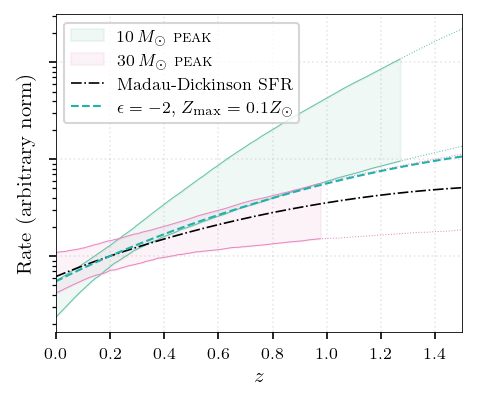

In [56]:
plot_and_compare_z_ppds("skewt_z", "2 local", ev_prob=skewt_z_2_prob, ev_wts=skewt_z_2_wts)

In [58]:
skewt_z_ABC_prob = get_event_probabilities("skewt_z", "A, B, C", submodel=True)
skewt_z_ABC_wts = get_pop_weighted_posteriors("skewt_z", "A, B, C", submodel=True)

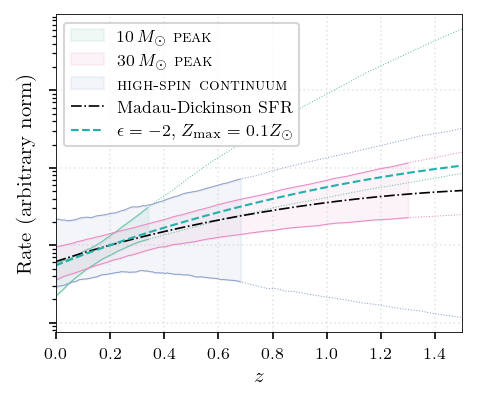

In [59]:
plot_and_compare_z_ppds("skewt_z", "A, B, C", submodel=True, ev_prob=skewt_z_ABC_prob, ev_wts=skewt_z_ABC_wts)


/tmp/ipykernel_1351370/3147249705.py:19: RuntimeWarning: invalid value encountered in divide
  low, high = low / norm, high / norm


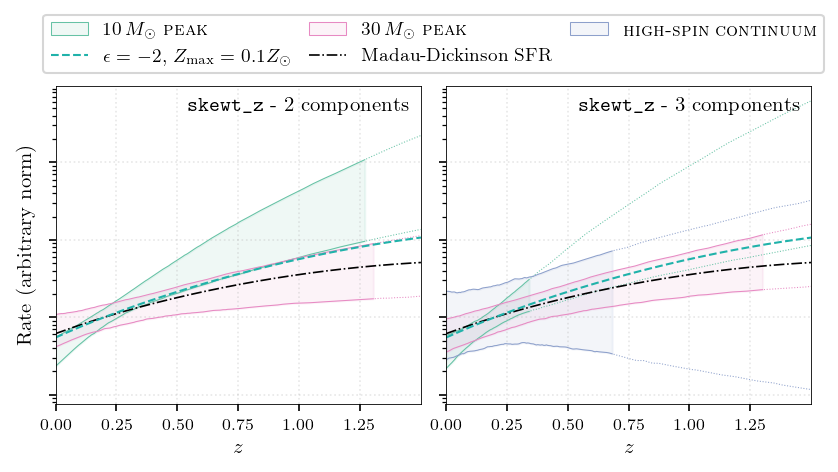

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.75), sharex=True, sharey=True)

plot_and_compare_z_ppds("skewt_z", "2 local", ax=axes[0], savefig=False,
                        ev_prob=skewt_z_2_prob, ev_wts=skewt_z_2_wts)
plot_and_compare_z_ppds("skewt_z", "A, B, C", submodel=True, ax=axes[1],
                        ev_prob=skewt_z_ABC_prob, ev_wts=skewt_z_ABC_wts, savefig=False)

axes[0].text(0.97, 0.97, get_title("skewt_z", "2 local"), transform=axes[0].transAxes,
             va="top", ha="right", fontsize=10)
axes[1].text(0.97, 0.97, get_title("skewt_z", "3 local"), transform=axes[1].transAxes,
             va="top", ha="right", fontsize=10)

for ax in axes:
    ax.get_legend().remove()
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1, 1.25])

axes[1].set_ylabel(None)
fig.subplots_adjust(wspace=0.07)

fig.canvas.draw()
pos_left  = axes[0].get_position()
pos_right = axes[1].get_position()
mid_x  = (pos_left.x0 + pos_right.x1) / 2
top_y  = max(pos_left.y1, pos_right.y1)

handles, labels = axes[1].get_legend_handles_labels()
handles = [handles[i] for i in [0, 4, 1, 3, 2]]
labels  = [labels[i]  for i in [0, 4, 1, 3, 2]]
leg = fig.legend(handles, labels, loc='lower center',
                 bbox_to_anchor=(mid_x, top_y + 0.01),
                 bbox_transform=fig.transFigure, ncol=3, fontsize=9, columnspacing=1)
for handle in leg.legend_handles:
    if isinstance(handle, Patch):
        fc = handle.get_facecolor()
        handle.set_edgecolor(to_rgba(fc, alpha=1.0))
        handle.set_linewidth(0.5)

fig.savefig(os.path.join(figpath, "skewt_z_sfr_dtd.pdf"))

## Redshift evolution of components

In [13]:
zs = (0, 0.5, 1)

def _filter_rates(arr):
    return np.where(~np.isfinite(arr) | (arr < 0), 0.0, arr)

def plot_pdf_given_z(param_name, model_name, model_sig, submodel=False, zs=zs,
                     palette="mako", norm=True, ylog=True, xlim=None, savefig=True):
    setup_data_module(model_name)
    model_draw_ctx = get_draw_ctx(model_name, model_sig, submodel)
    hyperparams = model_draw_ctx["samples_input"]
    labels = model_draw_ctx["labels_input"]
    xx = data_grid[param_name]
    xp_x = xp.asarray(xx)
    xp_hps = [xp.asarray(v) for v in hyperparams]
    fig, ax = plt.subplots()
    z_colors = sns.color_palette(palette, len(zs))
    for z, color in zip(zs, z_colors, strict=False):
        all_comp_pdfs, all_comp_rates = [], []
        for b_idx, (b_hps, b_labels) in enumerate(zip(hyperparams[:-1], labels[:-1])):
            rate = utils.to_numpy(data.eval_param_marginals(z, b_idx, "redshift", xp_hps)).squeeze() * b_hps[..., -1]
            rate = _filter_rates(rate)
            leaf_pdf = utils.to_numpy(data.eval_param_marginals(xp_x, b_idx, param_name, xp_hps))
            leaf_pdf = np.nan_to_num(leaf_pdf, nan=0.0, posinf=0.0, neginf=0.0)
            nsamples, ncomps, ngrid = leaf_pdf.shape
            ppd_by_label   = np.zeros((ncomps, nsamples, ngrid), dtype=np.float64)
            rate_by_label  = np.zeros((ncomps, nsamples), dtype=np.float64)
            for label in range(ncomps):
                w = (rate * (b_labels == label)).astype(np.float64)
                ppd_by_label[label]  = np.sum(leaf_pdf * w[..., None], axis=1)
                rate_by_label[label] = np.sum(w, axis=1)
            all_comp_pdfs.append(ppd_by_label)
            all_comp_rates.append(rate_by_label)
        all_comp_ppds  = np.concatenate(all_comp_pdfs, axis=0)
        all_comp_rates = np.concatenate(all_comp_rates, axis=0)
        if norm:
            all_comp_ppds  /= np.sum(all_comp_rates, axis=0, keepdims=True)[..., None]
            all_comp_rates /= np.sum(all_comp_rates, axis=0, keepdims=True)
        ppd_tot = np.sum(all_comp_ppds, axis=0)
        low, high = np.nanpercentile(ppd_tot, [5, 95], axis=0)
        ax.fill_between(xx, low, high, color=color, alpha=0.2, label=f"$z={z}$")
        ax.plot(xx, low,  color=color, lw=0.5)
        ax.plot(xx, high, color=color, lw=0.5)
    ax.set_xlabel(plot.param_latex[param_name])
    param_latex = plot.param_latex[param_name].strip("$")
    ax.set_ylabel(f"$p({param_latex})$" if norm else f"$\\mathrm{{d}}\\mathcal{{R}}/\\mathrm{{d}}{param_latex}$")
    if ylog:
        ax.set_yscale("log")
        ax.set_ylim(bottom=1e-4 * np.nanmax(high), top=2 * np.nanmax(high))
    else:
        ax.set_ylim(bottom=0, top=1.1 * np.nanmax(high))
    if xlim:
        ax.set_xlim(xlim)
    ax.legend()
    ax.set_title(get_title(model_name, model_sig), fontsize=10)
    if savefig:
        suffix = "" if norm else "_unnorm"
        fn_base = f"{model_name}_{utils.get_safe_fn(model_sig)}_{param_name}_evolution{suffix}"
        save_plot(fn_base, bbox_inches="tight")

In [14]:
def plot_p_z_peak_ratios(model_name, model_sig, submodel=False, peak_params=("mass_1_source", "chi_eff"), color="plum", savefig=True):
    setup_data_module(model_name)
    model_draw_ctx = get_draw_ctx(model_name, model_sig, submodel)
    hyperparams = model_draw_ctx["samples_input"]
    labels = model_draw_ctx["labels_input"]
    zz = data_grid["redshift"]
    xp_zz = xp.asarray(zz)
    xp_hps = [xp.asarray(v) for v in hyperparams]
    fig, ax = plt.subplots()

    comp_info_dict = get_comp_label_info(model_name)
    sig_10 = [sig for name, sig in zip(comp_info_dict["comp_names"], comp_info_dict["comp_sigs"]) if comp_name_dict[name] is A_name][0]
    sig_30 =  [sig for name, sig in zip(comp_info_dict["comp_names"], comp_info_dict["comp_sigs"]) if comp_name_dict[name] is B_name][0]

    # compare 10 Msun peak and 30 Msun peak
    tot_pdfs = []
    mu_dicts = []
    for comp_bn, comp_idx in (sig_10, sig_30):

        # find where the peak is
        comp_b_idx = data.branch_names.index(comp_bn)
        comp_b_labels = labels[comp_b_idx]
        comp_mask = (comp_b_labels == comp_idx).astype(bool)
        mu_to_param_map = dict(mass_1_source="$\\mu_m$", chi_eff="$\\mu_{\\chi}$", mass_ratio="$\\mu_{q}$")
        mu_dict = {}
        for param in peak_params:
            p_idx = data.hp_ordering[comp_b_idx]["__latex__"].index(mu_to_param_map[param])
            mu_dict[param] = float(np.median(hyperparams[comp_b_idx][comp_mask][..., p_idx]))
        mu_dicts.append(dict(mu_dict))
        print(mu_dict)

        for b_idx, b_hps in enumerate(hyperparams[:-1]):
            leaf_pdf = utils.to_numpy(data.eval_param_marginals(xp_zz, b_idx, "redshift", xp_hps)) * b_hps[..., -1][..., None]
            for param in peak_params:
                # evaluate at peak
                leaf_pdf = leaf_pdf * utils.to_numpy(data.eval_param_marginals(xp.atleast_1d(mu_dict[param]), b_idx, param, xp_hps))[..., None]

            leaf_pdf = np.nan_to_num(leaf_pdf, nan=0.0, posinf=0.0, neginf=0.0)
            # sum over components
            leaf_pdf = np.sum(leaf_pdf, axis=1) # nsamples, ngrid
            tot_pdfs.append(leaf_pdf)

    ppd_ratio = tot_pdfs[0] / tot_pdfs[1]
    plot.plot_ppds(ax, zz, ppd_ratio, color=color)
    ax.set_xlabel("$z$")
    mu_chi_30 = round(mu_dicts[1]['chi_eff'])
    rounded_mu_chi_30: str = str(mu_chi_30) if mu_chi_30 != 0 else "0"
    ax.set_ylabel(f"$\\frac{{\\mathcal{{R}}(z | m_1={mu_dicts[0]['mass_1_source']:.0f}\\,\\mathrm{{M}}_\\odot, \\,\\chi_\\mathrm{{eff}}={mu_dicts[0]['chi_eff']:.2f})}}{{\\mathcal{{R}}(z | m_1={mu_dicts[1]['mass_1_source']:.0f}\\,\\mathrm{{M}}_\\odot, \\, \\chi_\\mathrm{{eff}}={rounded_mu_chi_30})}}$")
    ax.set_xlim(0, 1.5)
    ax.set_title(get_title(model_name, model_sig), fontsize=10)
    if savefig:
        save_plot(f"{model_name}_{utils.get_safe_fn(model_sig)}_R_z_10_30_ratio")

### skewt_z

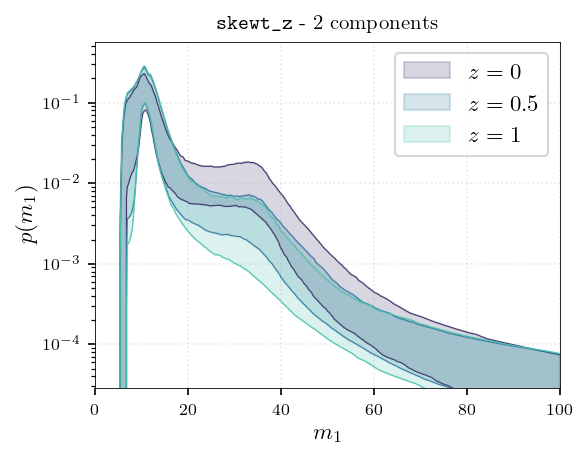

In [ ]:
plot_pdf_given_z("mass_1_source", "skewt_z", "2 local", xlim=(0,100))


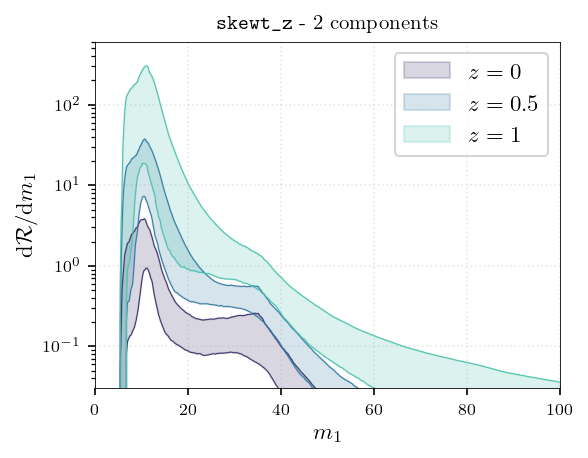

In [ ]:
plot_pdf_given_z("mass_1_source", "skewt_z", "2 local", norm=False, xlim=(0,100))


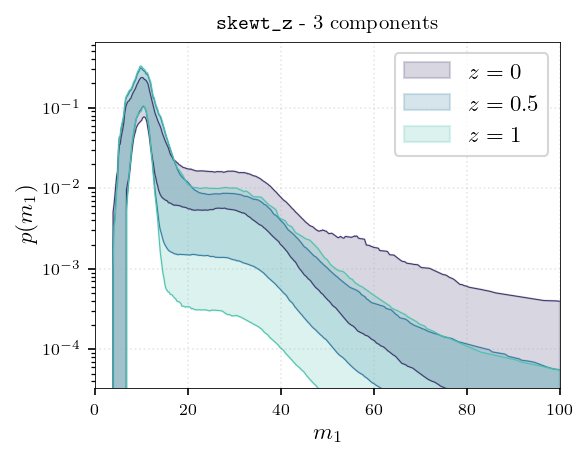

In [ ]:
plot_pdf_given_z("mass_1_source", "skewt_z", "3 local", norm=True, xlim=(0,100))


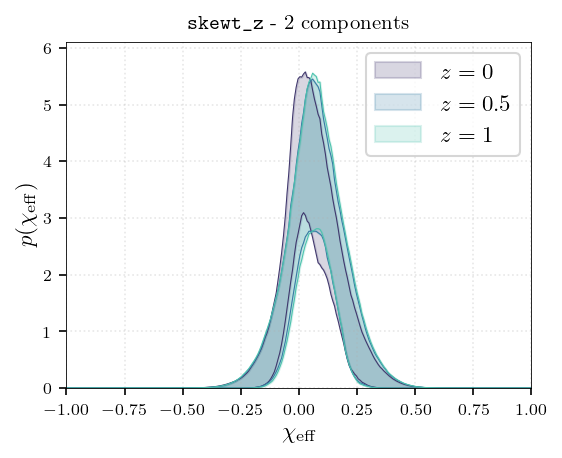

In [ ]:
plot_pdf_given_z("chi_eff", "skewt_z", "2 local", ylog=False, xlim=(-1,1))


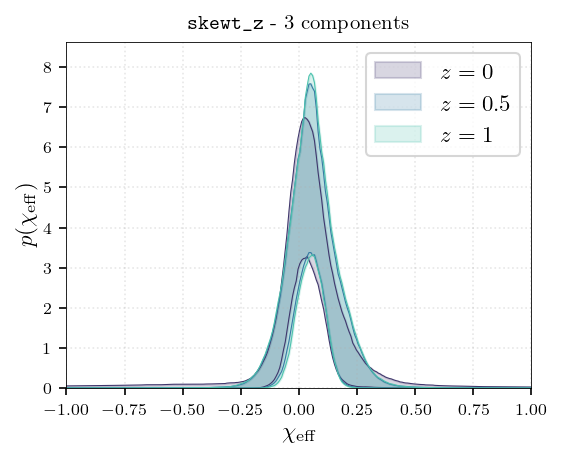

In [ ]:
plot_pdf_given_z("chi_eff", "skewt_z", "3 local", ylog=False, xlim=(-1,1))


### NPLNP

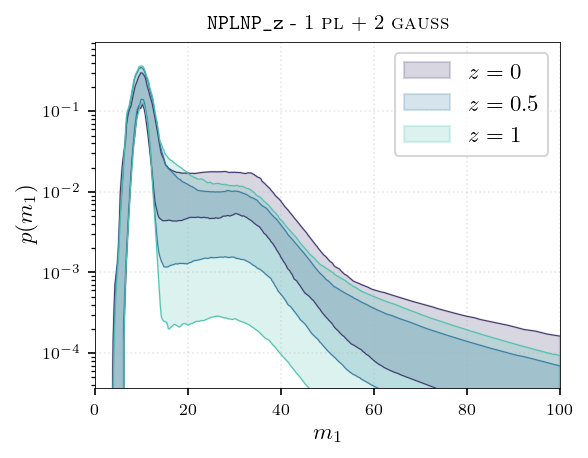

In [ ]:
plot_pdf_given_z("mass_1_source", "NPLNP_z", "PL A, gauss A, gauss B", submodel=True, xlim=(0,100))


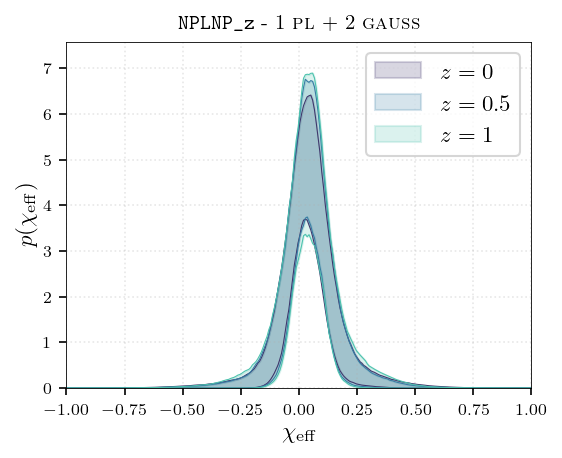

In [ ]:
plot_pdf_given_z("chi_eff", "NPLNP_z", "PL A, gauss A, gauss B", submodel=True, ylog=False, xlim=(-1,1))
